In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg
import random
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

In [3]:
def plotSTFT(
    signal, 
    Fs, 
    nperseg,
    noverlap,
    *,
    nfft = None, 
    window = 'boxcar',  # 'boxcar', 'hann', 'hamming', 'blackman', 'bartlett', 'flattop', 'parzen', 'bohman', 'blackmanharris', 'nuttall', 'barthann'
    Fmax = None, 
    F_lim = None,
    use_log_scale = False, 
    figsize = (16, 6), 
    cmap = 'viridis'
) -> None:

    f, t, spectrum = sg.stft(
        signal, 
        fs=Fs, 
        window=window, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        nfft=nfft, 
        return_onesided=False, 
        boundary=None, 
        padded=False
    )
    actual_nfft = nfft if nfft is not None else nperseg
    
    spectrum *= spectrum.shape[1] / nperseg
    
    f = np.fft.fftshift(f)
    spectrum = np.fft.fftshift(spectrum, axes=0)
    
    amplitude = np.abs(spectrum)
    
    plt.figure(figsize=figsize)

    if use_log_scale:
        display_data = 20 * np.log10(amplitude + 1e-12) 
        plt.ylabel("Frequency, Hz")
        plt.title("STFT Magnitude (dB)")
    else:
        display_data = amplitude
        plt.ylabel("Frequency, Hz")
        plt.title("STFT Magnitude")

    if len(t) == 1:
        dt = 1 / Fs
        df = Fs / actual_nfft
        
        R = nperseg - noverlap
        t_half_width = (R * dt) / 2
        
        t_edges = np.array([t[0] - t_half_width, t[0] + t_half_width])
        f_edges = np.append(f - df/2, f[-1] + df/2)
        
        plt.pcolormesh(t_edges, f_edges, display_data, shading='flat', cmap=cmap)
    else:   
        plt.pcolormesh(t, f, display_data, shading='nearest', cmap=cmap)
        
    plt.xlabel("Time, s")
    plt.colorbar(label='Amplitude' if not use_log_scale else 'dB')
    plt.rc("font", size=15)

    if F_lim:
        plt.ylim(F_lim)
    elif Fmax:
        plt.ylim((-Fmax, Fmax)) 
    else:
        plt.ylim((-Fs / 2, Fs / 2))

    plt.tight_layout()
    plt.show()

In [4]:
def plotSignalTime(signal, Fs, Tmax = None, label = None, linestyle=None, color=None, figsize=(16, 3)):
    dt = 1 / Fs
    t = np.linspace(0, len(signal)*dt, len(signal))
    plt.plot(t, signal, label=label, linestyle=linestyle, color=color)
    
    # Add empty borders
    if (Tmax):
        if (False): 
            plt.xlim((-Tmax*0.05, Tmax))
        else:
            plt.xlim((0, Tmax))
        
    #plt.stem(signal)
    plt.ylabel('Amplitude')
    plt.xlabel('time, s')
    plt.rc('font', size=15)
    
    if label:
        plt.legend()
        
    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [5]:
def plotAmplFreqResp(signal, Fs, Fmax=None, label=None, use_log_scale=False, plot_envelope=False, use_grid=True, dft_points=None, figsize=(16, 3), linestyle=None, color=None, multiplier=1):

    fft_signal = np.fft.fft(signal, n=dft_points)  # make FFT of info signal
    fft_signal *= multiplier
    fft_signal = np.fft.fftshift(fft_signal)  # shift FFT so that DC (zero frequency) is at center
    N = len(fft_signal)
    if use_log_scale:
        plt.plot(np.linspace(-Fs / 2, Fs / 2 - Fs / N, N), 20 * np.log10(np.abs(fft_signal)), label=label, linestyle=linestyle, color=color)
        plt.ylabel("Amplitude, dB")
    else:
        plt.plot(np.linspace(-Fs / 2, Fs / 2 - Fs / N, N), np.abs(fft_signal), label=label, linestyle=linestyle, color=color)
        plt.ylabel("Amplitude")
    plt.xlabel("Frequency, Hz")
    plt.rc("font", size=15)

    # Add empty borders
    if Fmax:
        plt.xlim((-Fmax, Fmax))
    else:
        plt.xlim((0, Fs / 2))

    if plot_envelope:
        if use_log_scale:
            db_fft_signal = 20 * np.log10(np.abs(fft_signal))
            filt = sg.bessel(1, 1000, "low", fs=Fs, output="sos")
            db_fft_signal_filtered = sg.sosfilt(filt, db_fft_signal)
            envelope = np.abs(sg.hilbert(db_fft_signal_filtered))
            plt.plot(np.linspace(-Fs / 2, Fs / 2 - Fs / N, N), envelope, color="r")

    if use_grid:
        plt.grid(visible=1, which="both")
        plt.minorticks_on()
        plt.grid(which="major", linewidth=2)
        plt.grid(which="minor", linestyle=":")
    if label:
        plt.legend()

    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [6]:
def plotAmplFreqRespOfFilter(filt, Fs, Fmax=None, label=None, use_log_scale=False, plot_envelope=False, use_grid=True, dft_points=1024, figsize=(16, 3), linestyle=None, color=None, multiplier=1):

    w, h = sg.freqz_sos(filt, worN=dft_points, fs=Fs, whole=True)
    
    w = np.fft.fftshift(np.fft.fftfreq(dft_points, d=1/Fs))
    h = np.fft.fftshift(h)
    
    amplitude = np.abs(h) * multiplier

    if use_log_scale:
        display_amp = 20 * np.log10(amplitude + 1e-12)
        plt.ylabel("Amplitude, dB")
    else:
        display_amp = amplitude
        plt.ylabel("Amplitude")

    plt.plot(w, display_amp, label=label, linestyle=linestyle, color=color)
    plt.xlabel("Frequency, Hz")
    plt.rc("font", size=12)

    if Fmax:
        plt.xlim((-Fmax, Fmax))
    else:
        plt.xlim((-Fs / 2, Fs / 2))

    if use_grid:
        plt.grid(visible=True, which="major", linewidth=1.5)
        plt.grid(visible=True, which="minor", linestyle=":", alpha=0.6)
        plt.minorticks_on()

    if label:
        plt.legend()

    plt.tight_layout()
    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [7]:
def plotPhaseFreqResp(signal, Fs, Fmax=None, use_grid=True, dft_points=None, label=None, linestyle=None, color=None, figsize=(16, 3)):
    
    fft_signal = np.fft.fftshift(np.fft.fft(signal, n=dft_points))

    N = len(fft_signal)

    plt.plot(np.linspace(-Fs / 2, Fs / 2 - Fs / N, N), np.unwrap(np.angle(fft_signal)), label=label, linestyle=linestyle, color=color)
    plt.ylabel("Phase")
    plt.xlabel("Frequency, Hz")
    plt.rc("font", size=15)

    # Add empty borders
    if Fmax:
        plt.xlim((-Fmax, Fmax))
    else:
        plt.xlim((0, Fs / 2))

    if use_grid:
        plt.grid(visible=1, which="both")
        plt.minorticks_on()
        plt.grid(which="major", linewidth=2)
        plt.grid(which="minor", linestyle=":")

    if label:
        plt.legend()

    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [8]:
def plotPhaseFreqRespOfFilter(filt, Fs, Fmax=None, label=None, use_grid=True, dft_points=1024, figsize=(16, 3), linestyle=None, color=None):

    w, h = sg.freqz_sos(filt, worN=dft_points, fs=Fs, whole=True)
    
    w = np.fft.fftshift(np.fft.fftfreq(dft_points, d=1/Fs))
    h = np.fft.fftshift(h)
    
    phase = np.unwrap(np.angle(h))

    plt.plot(w, phase, label=label, linestyle=linestyle, color=color)
    plt.ylabel("Phase [rad]")
    plt.xlabel("Frequency, Hz")
    plt.rc("font", size=12)

    if Fmax:
        plt.xlim((-Fmax, Fmax))
    else:
        plt.xlim((-Fs / 2, Fs / 2))

    if use_grid:
        plt.grid(visible=True, which="both")
        plt.minorticks_on()
        plt.grid(which="major", linewidth=1.5)
        plt.grid(which="minor", linestyle=":", alpha=0.6)

    if label:
        plt.legend()

    plt.tight_layout()
    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [9]:
def plotGroupDelayOfFilter(filt, Fs, Fmax=None, label=None, use_grid=True, dft_points=512, figsize=(16, 3), linestyle=None, color=None):

    b, a = sg.sos2tf(filt)
    w, gd = sg.group_delay((b, a), w=dft_points, fs=Fs, whole=True)
    
    w = np.fft.fftfreq(dft_points, d=1/Fs)
    w = np.fft.fftshift(w)
    gd = np.fft.fftshift(gd)
    
    gd_ms = (gd / Fs) * 1000

    plt.plot(w, gd_ms, label=label, linestyle=linestyle, color=color)
    plt.ylabel("Group Delay, ms")
    plt.xlabel("Frequency, Hz")
    plt.rc("font", size=12)

    if Fmax:
        plt.xlim((-Fmax, Fmax))
    else:
        plt.xlim((-Fs / 2, Fs / 2))

    if use_grid:
        plt.grid(visible=True, which="both")
        plt.minorticks_on()
        plt.grid(which="major", linewidth=1.5)
        plt.grid(which="minor", linestyle=":", alpha=0.6)

    if label:
        plt.legend()

    plt.tight_layout()
    fig = plt.gcf()
    fig.set_size_inches(figsize)

# Digital modulations

Pipeline:

- A1 - Baseband signal: Turn bit sequence into baseband signal. 
- B1 - Pre-modulation filter: If required, filter signal before modulation. (Not included in initial file version)
- C1 - Modulation: Apply baseband signal to a carrier to create modulated signal.
- D - Channel: Pass the signal through noisy channel.  
- C2 - Demodulation: Get baseband signal from the modulated signal - multiply by the carrier. 
- B2 - Demodulation filter: Use an LPF.
- A2 - Detection: Get bit sequence from the baseband signal.

__First try detecting bit sequence with only A-steps. Next, introduce B-steps. Then, C-steps. Finally, D.__

### Reminders
Plot appropriate pictures. Ensure you understand what is going on. Bad graphs reduce your rating
Ask questions if needed.

## A1 - Baseband signal 

In [10]:
def make_wide(data_symbols, samples_per_symbol, scale_multiplier):
    return np.kron(data_symbols, np.tile(scale_multiplier, samples_per_symbol))

def undo_make_wide(wide_data, samples_per_symbol, scale_multiplier):
    reshaped = wide_data.reshape(-1, samples_per_symbol)
    return reshaped[:, 0] / scale_multiplier

In [11]:
Fs = 200_000  # samples/s
dt = 1 / Fs
samples_per_symbol = 100  # samples
symbol_duration = samples_per_symbol / Fs  # seconds
print("symbol_duration", symbol_duration)

bits_per_symbol = 2
alphabet_size = 2**bits_per_symbol

data_size_symbols = 100  # Use at least 50 bits
data_size_bits = data_size_symbols * bits_per_symbol
data_symbols = np.random.randint(alphabet_size, size=data_size_symbols)
print("data_size_bits", data_size_bits)
print("data_symbols", data_symbols)

norm_factor = np.sqrt((alphabet_size-1) * (alphabet_size+1) / 3) 
print(f"norm_factor={norm_factor}")

scale_multiplier = 2
baseband_signal = make_wide(data_symbols, samples_per_symbol=samples_per_symbol, scale_multiplier=scale_multiplier)
baseband_signal = baseband_signal - (alphabet_size - 1)  # DC removal
print(f"baseband_signal={baseband_signal}")
normalized_baseband_signal = baseband_signal / norm_factor  # Normalization 
 
t = np.linspace(0, len(normalized_baseband_signal)*dt, len(normalized_baseband_signal))

symbol_duration 0.0005
data_size_bits 200
data_symbols [3 2 3 2 1 2 3 1 1 3 1 2 3 0 2 3 2 3 1 2 0 1 0 3 2 3 1 0 1 0 3 0 0 0 1 1 1
 2 2 2 0 1 3 0 2 1 1 2 2 1 0 1 2 0 2 3 0 3 0 2 3 0 2 3 3 0 1 0 3 1 2 0 3 1
 3 0 1 1 2 0 0 0 0 0 0 2 2 1 0 0 2 3 2 1 2 1 1 3 1 0]
norm_factor=2.23606797749979
baseband_signal=[ 3  3  3 ... -3 -3 -3]


In [12]:
def plot_symbols(normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label=None, linestyle=None, color=None, figsize=(16, 3)):
    dt = 1 / Fs
    Tmax = symbols_to_plot*samples_per_symbol*dt
    plotSignalTime(normalized_baseband_signal, Fs, Tmax, label=label, linestyle=linestyle, color=color, figsize=figsize)
    plt.xticks(np.arange(0, Tmax, samples_per_symbol*dt), rotation=45, fontsize=8)
    plt.grid(True, axis='x')

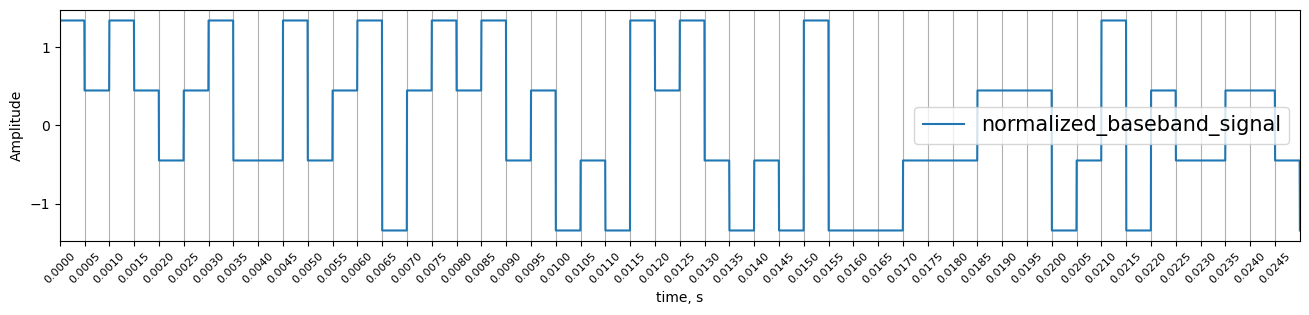

In [13]:
symbols_to_plot = 50

plot_symbols(normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='normalized_baseband_signal')

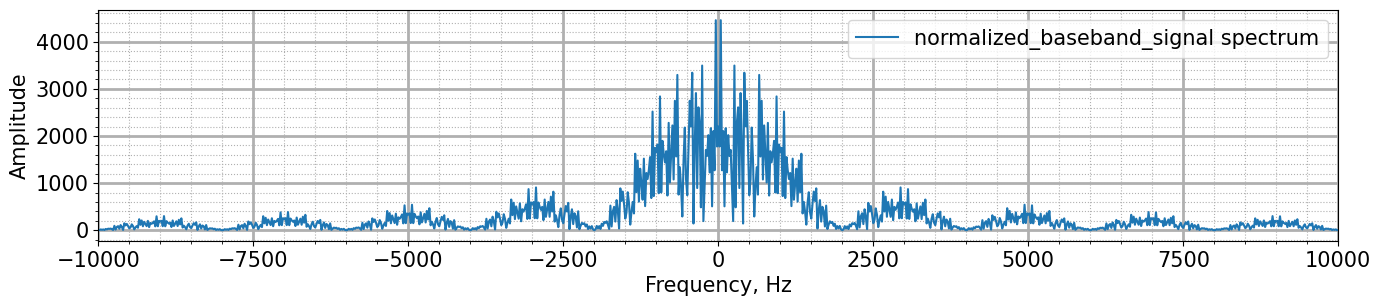

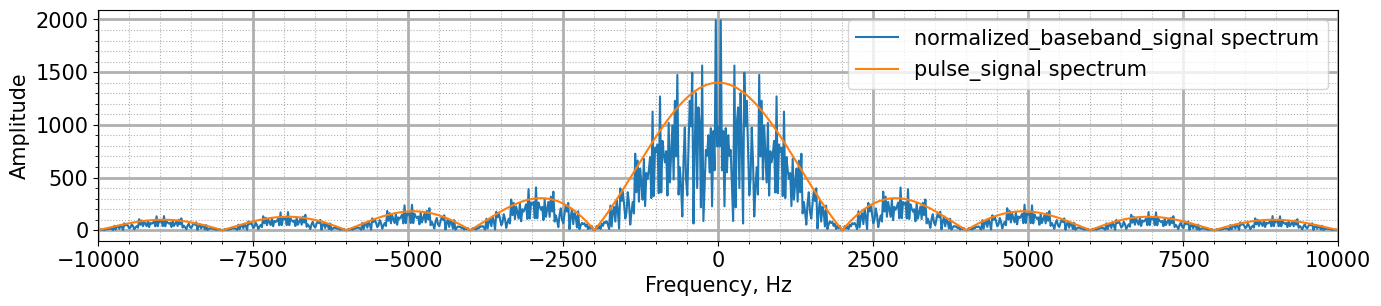

In [ ]:
use_log = False
Fmax = Fs / 2 / 10

# plotAmplFreqResp(baseband_signal, Fs, Fmax, use_log_scale=use_log, label='normalized_baseband_signal spectrum')
plt.show()
plotAmplFreqResp(normalized_baseband_signal, Fs, Fmax, use_log_scale=use_log, label='normalized_baseband_signal spectrum')

meander = np.tile(0.5, samples_per_symbol)
meander = np.concatenate([meander, -meander])
meander = np.tile(meander, data_size_symbols)
# plotAmplFreqResp(meander, Fs, Fmax, use_log_scale=use_log)

pulse_signal = np.tile(0, data_size_symbols*samples_per_symbol)
pulse_signal[0:samples_per_symbol] = np.sqrt(data_size_bits)
plotAmplFreqResp(pulse_signal, Fs, Fmax, use_log_scale=use_log, label='pulse_signal spectrum')

if use_log:
    plt.ylim((-10,40))

(-10.0, 1900.0)

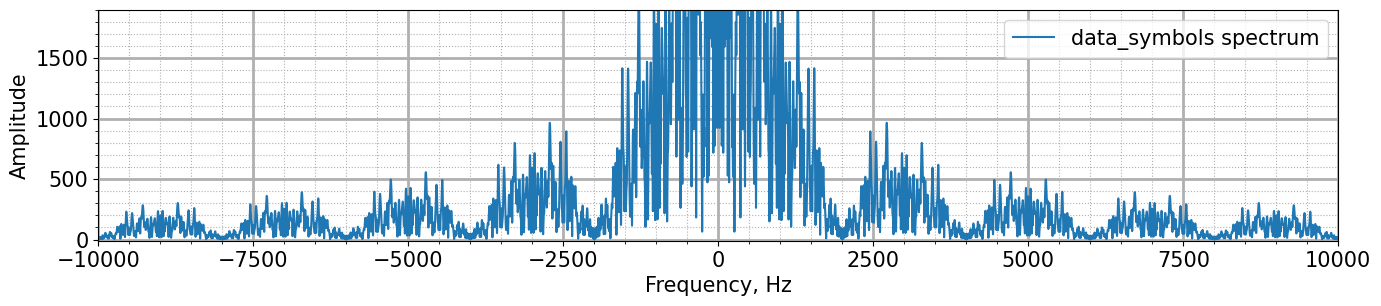

In [345]:
plotAmplFreqResp(make_wide(data_symbols, samples_per_symbol, 2), Fs, Fmax, use_log_scale=use_log, dft_points=1000000, label='data_symbols spectrum')

plt.ylim(-10, 1900)

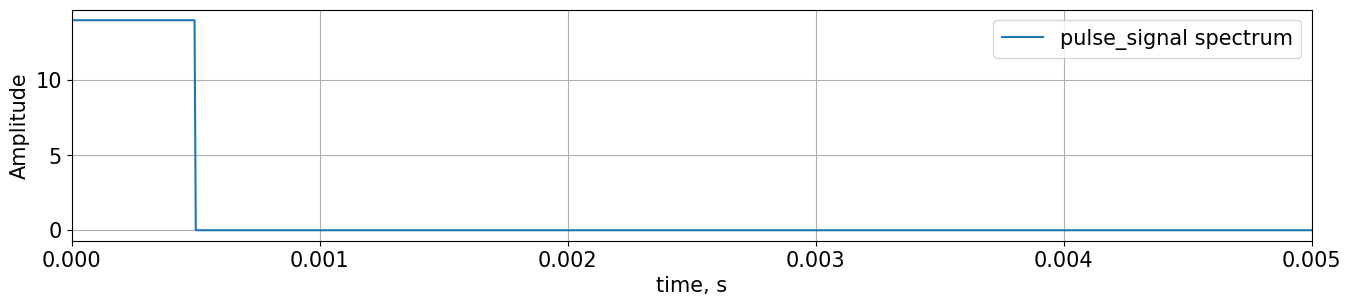

In [346]:
plotSignalTime(pulse_signal, Fs, Tmax=0.005, label='pulse_signal spectrum')

plt.grid(True)

## B1 - Pre-modulation filter

### Example: Applying ideal LPF to see baseband signal reaction
NOTE: Filtering prior to modulation is not strictly neccesary but used very often. Parameters depend on baseband signal, carrier and channel properties.  

In [347]:
use_log = False

fft_signal = np.fft.fft(normalized_baseband_signal)
bw = 1/symbol_duration
cutoff_freq = bw * 3
freq_samples_to_filter = int(cutoff_freq * len(fft_signal)/Fs)

fft_signal[(freq_samples_to_filter):(len(fft_signal)-freq_samples_to_filter)] = 0
filtered_signal = np.real(np.fft.ifft(fft_signal)) #Comment: signal is real. Added np.real() to remove machine error. 


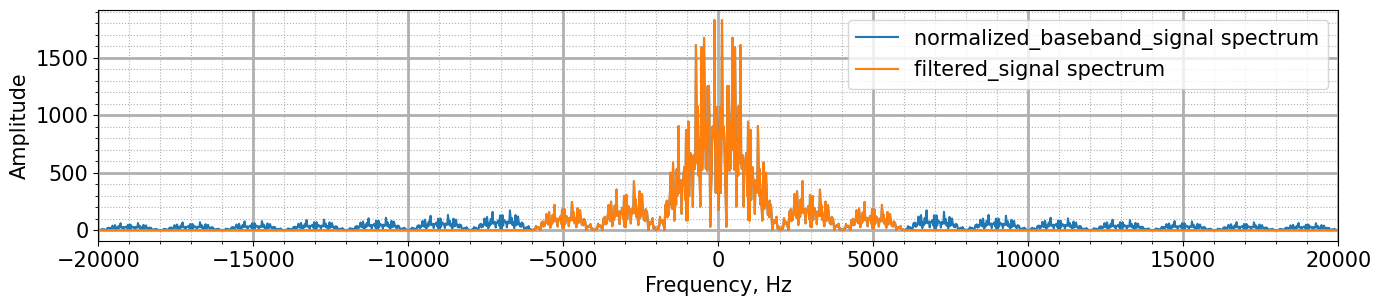

In [348]:
Fmax = Fs / 2 / 5

plotAmplFreqResp(normalized_baseband_signal, Fs, Fmax, use_log_scale=use_log, label='normalized_baseband_signal spectrum')
plotAmplFreqResp(filtered_signal, Fs, Fmax, use_log_scale=use_log, label='filtered_signal spectrum')

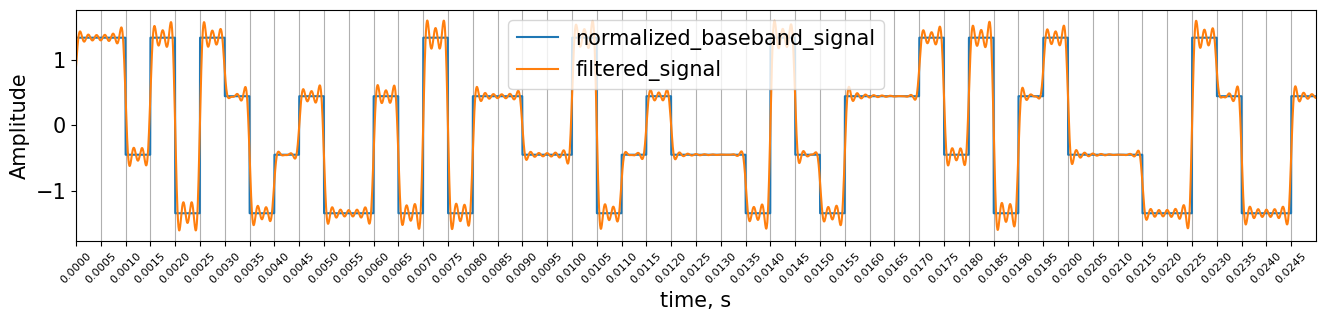

In [349]:
#NOTE: Please plot only COMPREHENCIBLE TIME PLOTS with signals, even for long signals! 50 symbols are recommended.
symbols_to_plot = 50
Tmax = symbols_to_plot*samples_per_symbol*dt

plot_symbols(normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='normalized_baseband_signal')
plot_symbols(filtered_signal, symbols_to_plot, samples_per_symbol, Fs, label='filtered_signal')

NOTE: Observe the overshoots and undershoots.

### B1 - применение фильтра Бесселя

In [350]:
should_filter = True

baud_rate = 1 / symbol_duration  # Еще это совпадает с bw (bandwidth)
cutoff_freq = baud_rate * 20

# в формате second-order sections (sos) для численной стабильности
sos_bessel = sg.bessel(N=2, Wn=cutoff_freq, btype='low', fs=Fs, output='sos')

# Применяем фильтр к normalized_baseband_signal двунаправленно, чтобы избежать задержки
premod_filtered_signal = sg.sosfiltfilt(sos_bessel, normalized_baseband_signal) if should_filter else normalized_baseband_signal

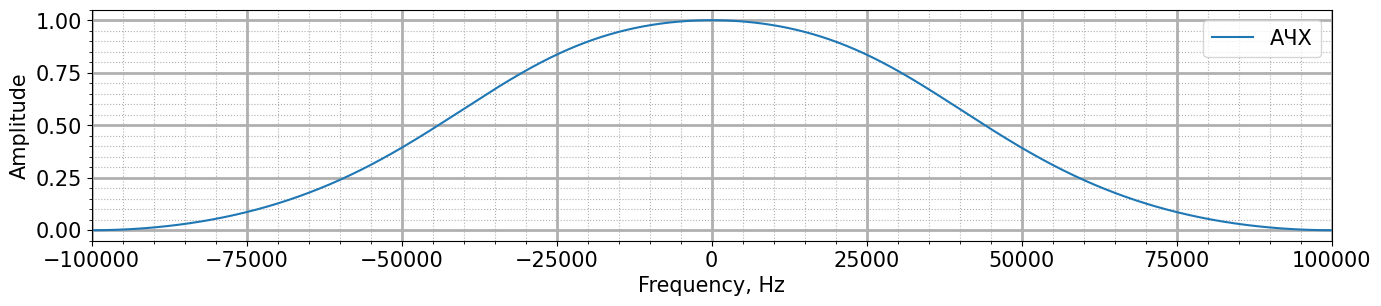

In [351]:
use_log = False

Fmax = Fs / 2

delta_impulse = np.zeros(samples_per_symbol * data_size_symbols)
delta_impulse[0] = 1.0
h_response = sg.sosfilt(sos_bessel, delta_impulse)

plotAmplFreqResp(h_response, Fs, Fmax, use_log_scale=use_log, label='АЧХ', figsize=(16, 3))

# plt.ylim((-10, 30))

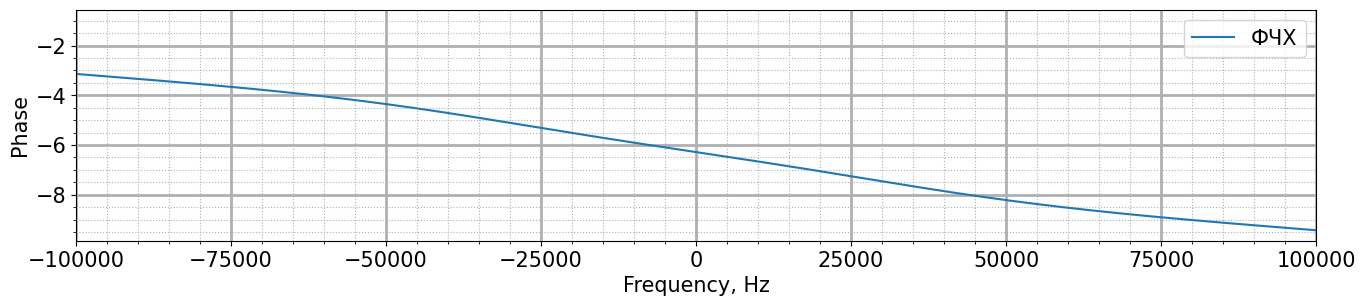

In [352]:
plotPhaseFreqResp(h_response, Fs, Fmax, label='ФЧХ', figsize=(16, 3))

C:\Users\Skifv\AppData\Local\Temp\ipykernel_20044\3869049382.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(-Fs / 2, Fs / 2 - Fs / N, N), 20 * np.log10(np.abs(fft_signal)), label=label, linestyle=linestyle, color=color)


(-10.0, 75.0)

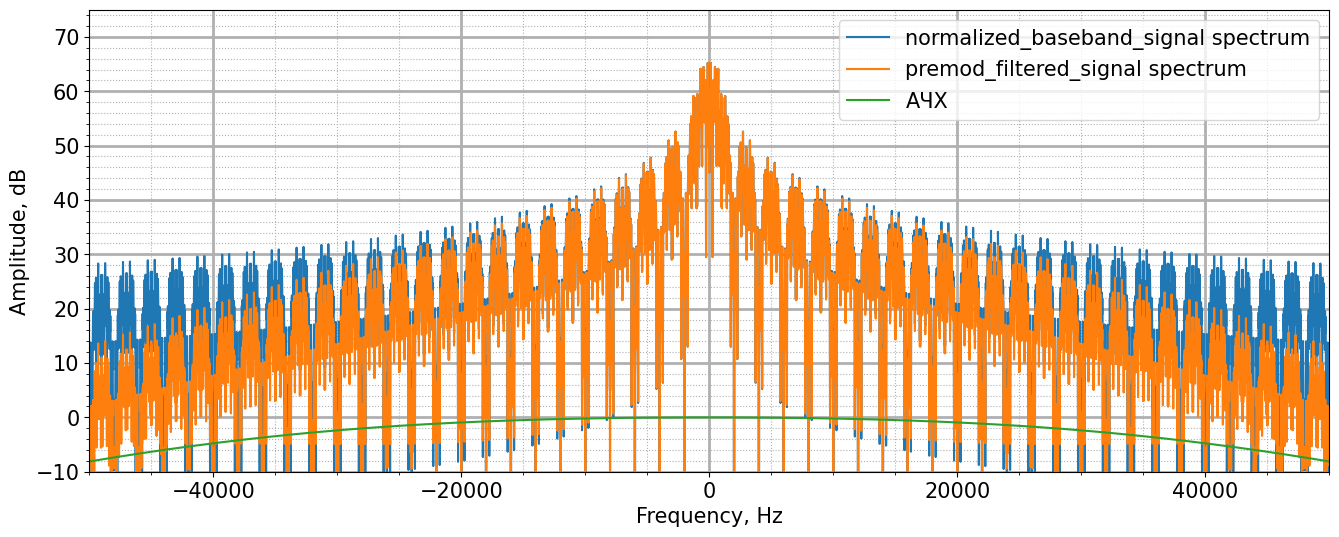

In [353]:
Fmax = Fs / 2 / 2
use_log = True

plotAmplFreqResp(normalized_baseband_signal, Fs, Fmax, use_log_scale=use_log, label='normalized_baseband_signal spectrum', figsize=(16, 6))
plotAmplFreqResp(premod_filtered_signal, Fs, Fmax, use_log_scale=use_log, label='premod_filtered_signal spectrum', figsize=(16, 6))
plotAmplFreqResp(h_response, Fs, Fmax, use_log_scale=use_log, label='АЧХ', figsize=(16, 6))

plt.ylim((-10, 75))

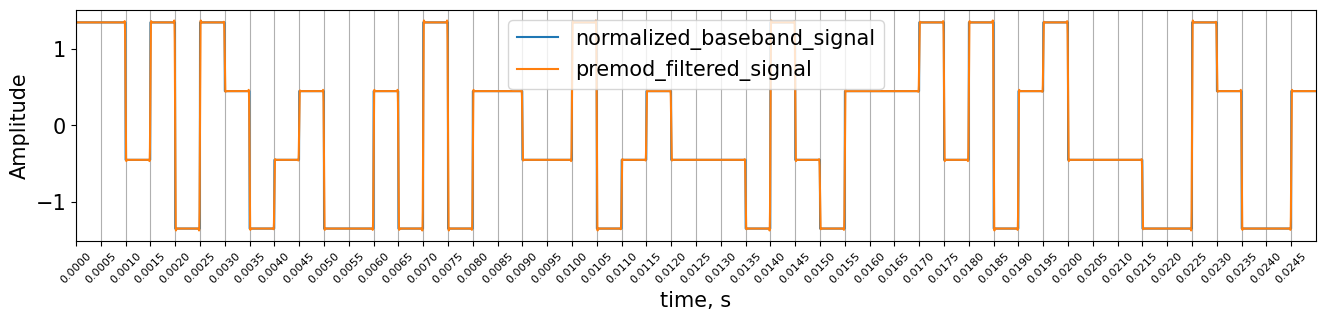

In [354]:

#NOTE: Please plot only COMPREHENCIBLE TIME PLOTS with signals, even for long signals! 50 symbols are recommended.
symbols_to_plot = 50

plot_symbols(normalized_baseband_signal,        symbols_to_plot, samples_per_symbol, Fs, label='normalized_baseband_signal')
plot_symbols(premod_filtered_signal, symbols_to_plot, samples_per_symbol, Fs, label='premod_filtered_signal')

## C1 - Modulation

### Example: ASK modulation

In [355]:
def modulateAM(modulator, f_c, f_s, modulation_index, t = []):
    dt = 1 / f_s
    if len(t) == 0:
        t = np.linspace(0, len(modulator) * dt, len(modulator))
    return (1 + modulation_index * modulator) * np.sin(2*np.pi*f_c*t) #use sin to match sin zeros to symbol change moments.

In [356]:
symbols_to_plot = 30
Tmax = symbols_to_plot*samples_per_symbol*dt

Fc = 4000 #Hz
m = 0.3
ask_signal = modulateAM(premod_filtered_signal, Fc, Fs, m, t)

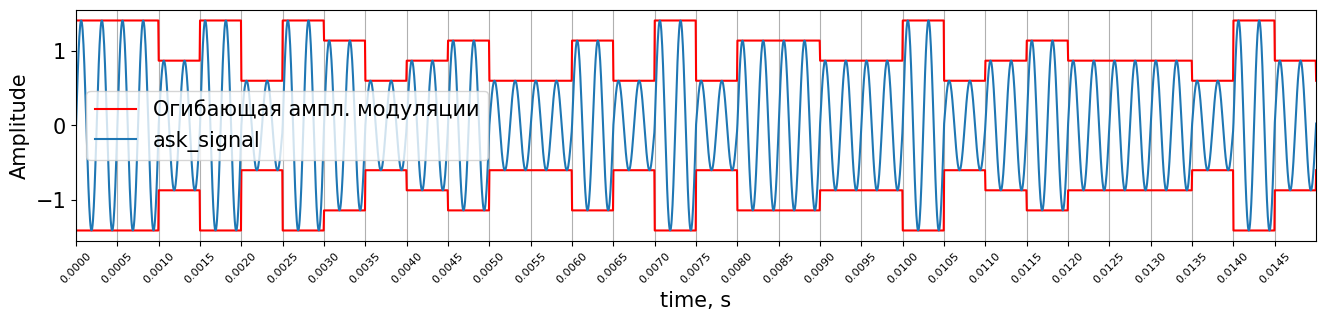

In [357]:
plot_symbols(1+m*normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
plot_symbols(-(1+m*normalized_baseband_signal), symbols_to_plot, samples_per_symbol, Fs, color='red')
plot_symbols(ask_signal, symbols_to_plot, samples_per_symbol, Fs, label='ask_signal')

(-15.0, 60.0)

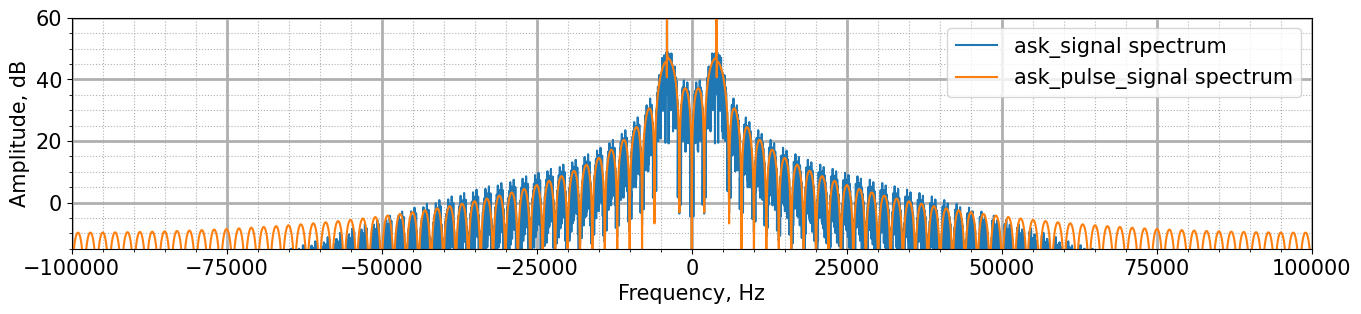

In [358]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(ask_signal, Fs, Fmax, use_log_scale=use_log, label='ask_signal spectrum')

ask_pulse_signal = modulateAM(pulse_signal, Fc, Fs, m, t)
plotAmplFreqResp(ask_pulse_signal, Fs, Fmax, use_log_scale=use_log, label='ask_pulse_signal spectrum')

plt.ylim((-15, 60))

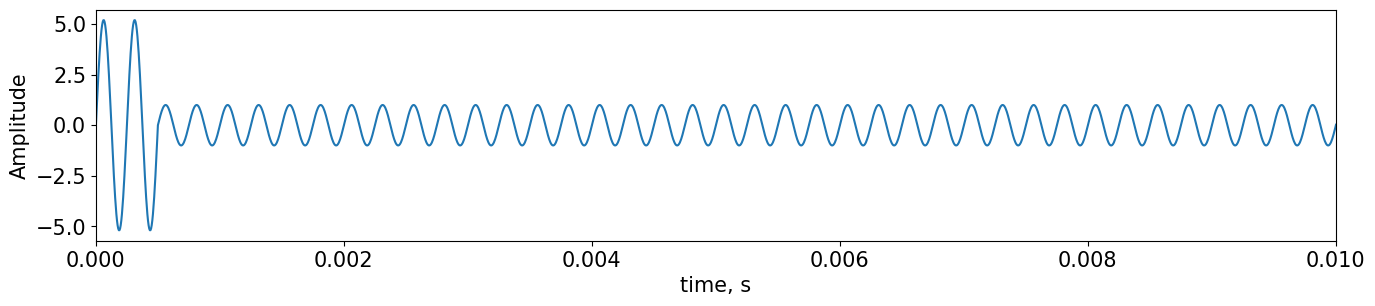

In [359]:
plotSignalTime(ask_pulse_signal, Fs, Tmax=0.01)

### HW6: Realize an EASY modulation.
 
Sort your group by last name is alphabetical order. Identify your number N, start with 0.
Select modulation x = N mod 3:

 0) BPSK
 1) QPSK
 2) FSK (select m from [0.5, 1.0, 1.5, ...])
 
NOTE: Make sure your signal parameters and the filter parametes match!

If want to change or select another than ones from the list, contact teacher :)

FSK: $s(t) = \cos(2\pi (f_c + f_d \cdot s_m(t))t)$           

CPFSK $s(t) = \cos(2\pi f_c t + 2 \pi f_d \int s_m(t) dt)$  

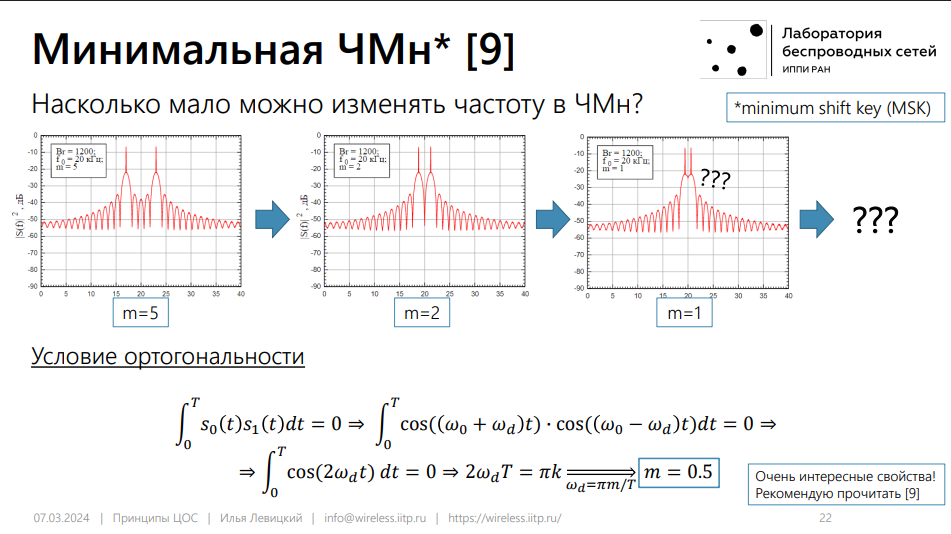

Делаю CPFSK, а не FSK, потому что так договорились с преподавателем. На сдаче посмотрели, как ведет себя FSK - он более "шумный", но демодудировать вполне успешно получается

In [360]:
def modulateCPFSK(modulator, f_c, f_s, f_d, t=[]):
    dt = 1 / f_s
    if len(t) == 0:
        t = np.linspace(0, len(modulator) * dt, len(modulator))

    return np.cos(2 * np.pi * f_c * t + 2 * np.pi * f_d * np.cumsum(modulator) * dt)

def modulateFSK(modulator, f_c, f_s, f_d, t=[]):
    dt = 1 / f_s
    if len(t) == 0:
        t = np.linspace(0, len(modulator) * dt, len(modulator))

    return np.cos(2 * np.pi * (f_c + f_d * modulator) * t)

$m = 2 f_d T_s = 2 f_d / f_b$, где $T_s$ - длительность символа, $f_b = 1/T_s$ ~ полуширина центрального лепестка

Минимальный m, когда частотные компоненты можно различить, получается из условия ортогональности: $m = 0.5$. В этом случае $f_d = f_b / 4$

In [361]:
modulation_func = modulateCPFSK

m = 2

Fb = 1 / symbol_duration

Fc = 40000  # Гц
Fd = m * Fb / 2  # Гц

print(f"Fd={Fd}")

# Де-нормализация для получения целых индексов уровней как уровней частоты
baseband_discrete_levels = premod_filtered_signal * norm_factor

cpfsk_signal = modulation_func(baseband_discrete_levels, Fc, Fs, Fd, t)


Fd=2000.0


Если включить FSK, то видны скачки фаз на графике ниже в переходах между символами

График выглядит неидеально (артефакты отрисовки), потому что пришлось выбрать несущую на высокой частоте (использование медленно спадающего фильтра Бесселя того требует)

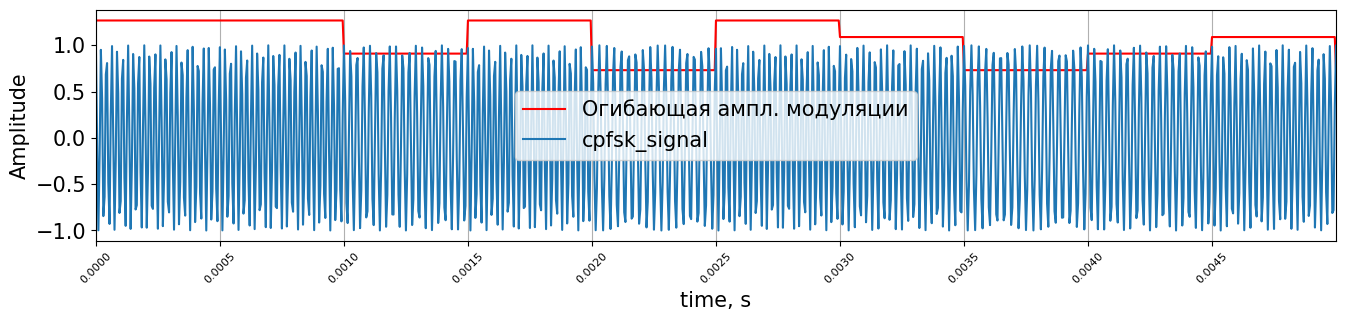

In [362]:
symbols_to_plot=10

scale_factor = 0.2

plot_symbols(1+scale_factor*normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
plot_symbols(cpfsk_signal, symbols_to_plot, samples_per_symbol, Fs, label='cpfsk_signal')

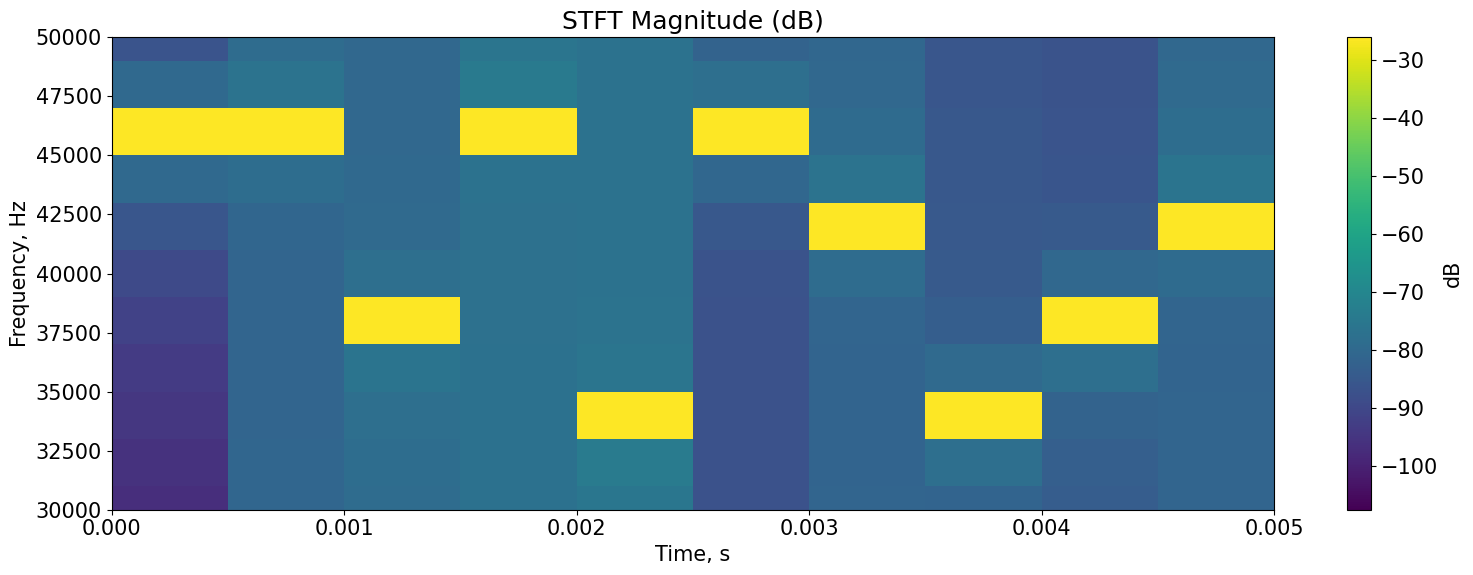

In [363]:
plotSTFT(cpfsk_signal[0:samples_per_symbol*10], 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol, 
         F_lim=(30_000, 50_000),  
         use_log_scale=True)

(-10.0, 70.0)

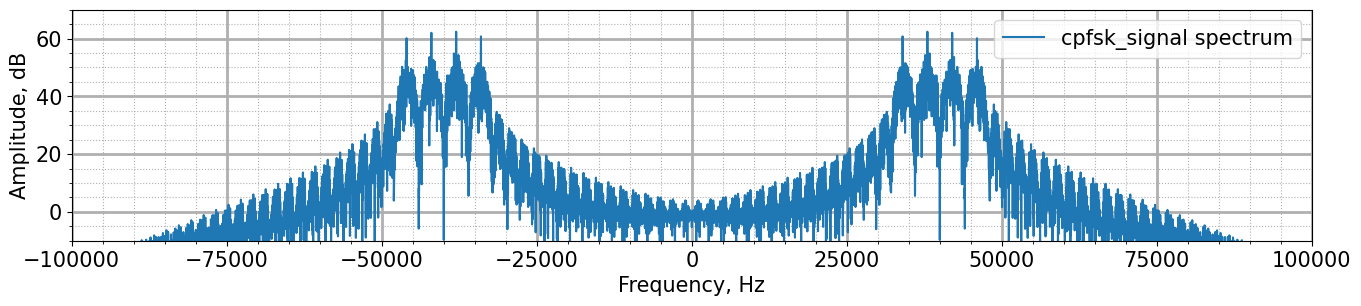

In [364]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(cpfsk_signal, Fs, Fmax, use_log_scale=use_log, label='cpfsk_signal spectrum')

plt.ylim((-10, 70))

#### HW7*: Write a short theoretical snippet about your modulation.
Consider main attributes, means of modulation and demodulation. Make references if needed.

Не сегодня...

### HW8: Realize a NORMAL modulation.

Sort your group by last name is alphabetical order. Identify your number N, start with 0.
Select modulation x = N mod 4:

 0) QBPSK
 1) OQPSK
 2) CPFSK (select m from [0.5, 1.0, 1.5, ...])
 3) X-QAM (select X from [16, 64, 256, ...])
 
If want to change or select another than ones from the list, contact teacher :)

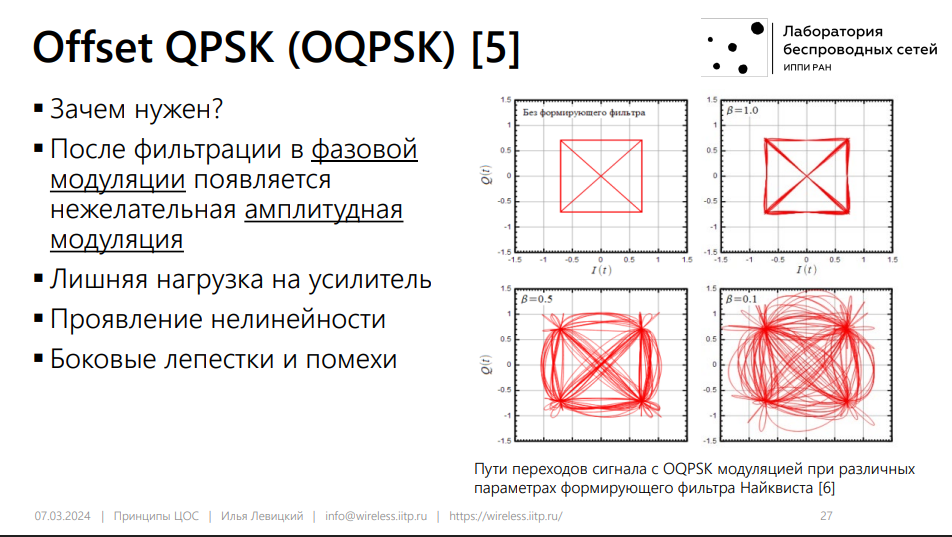
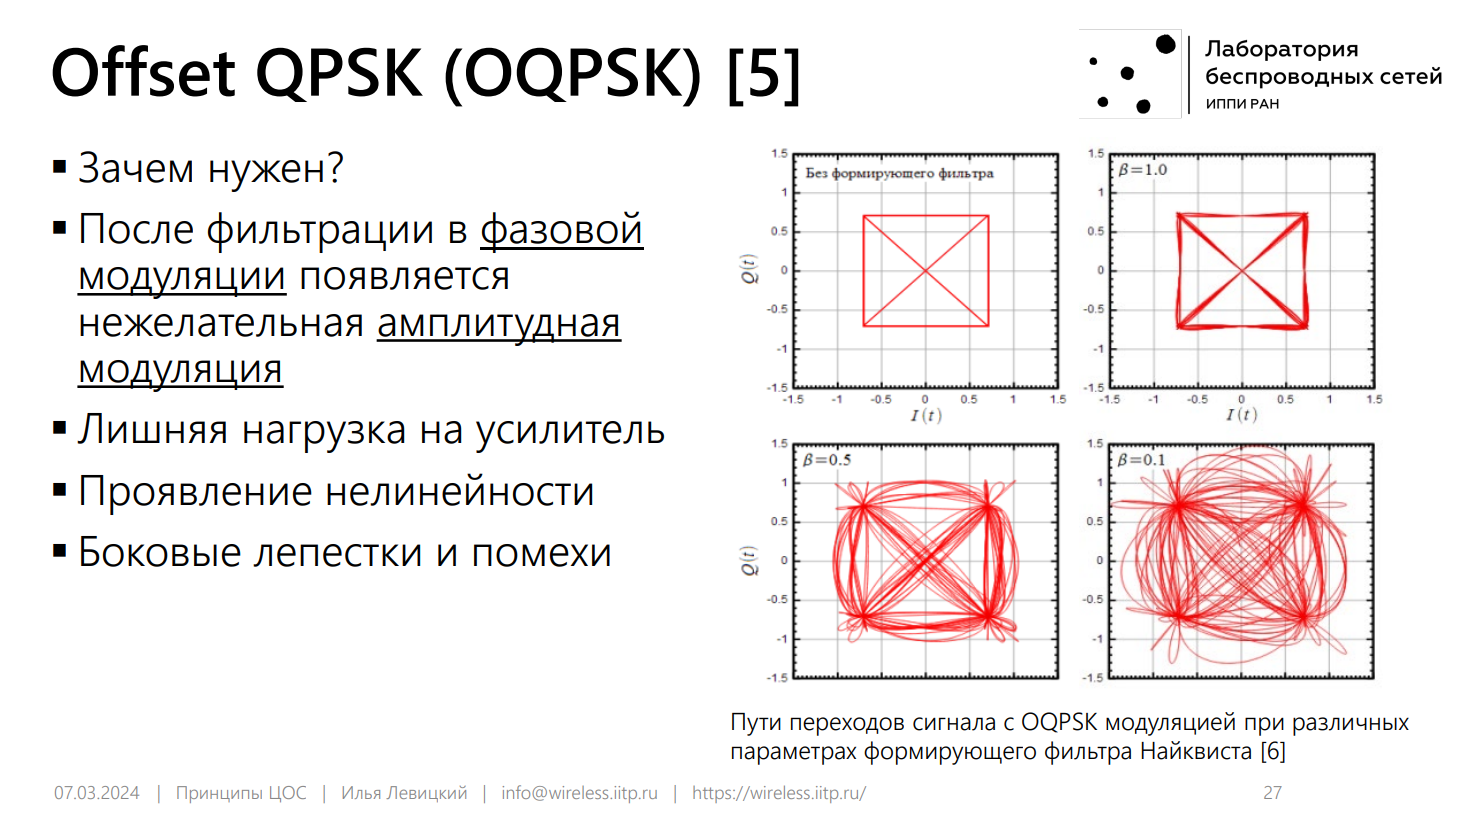
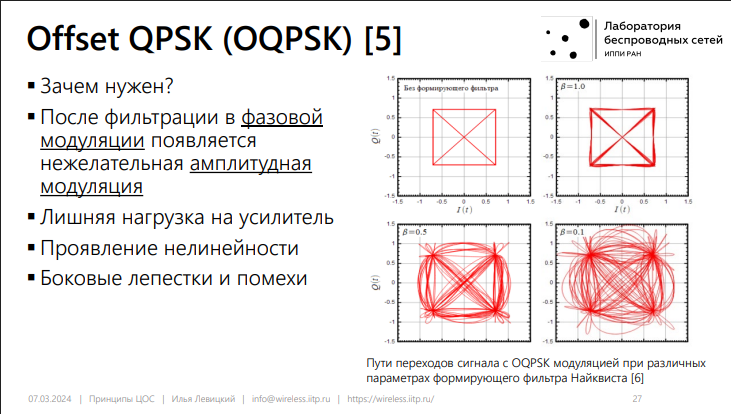

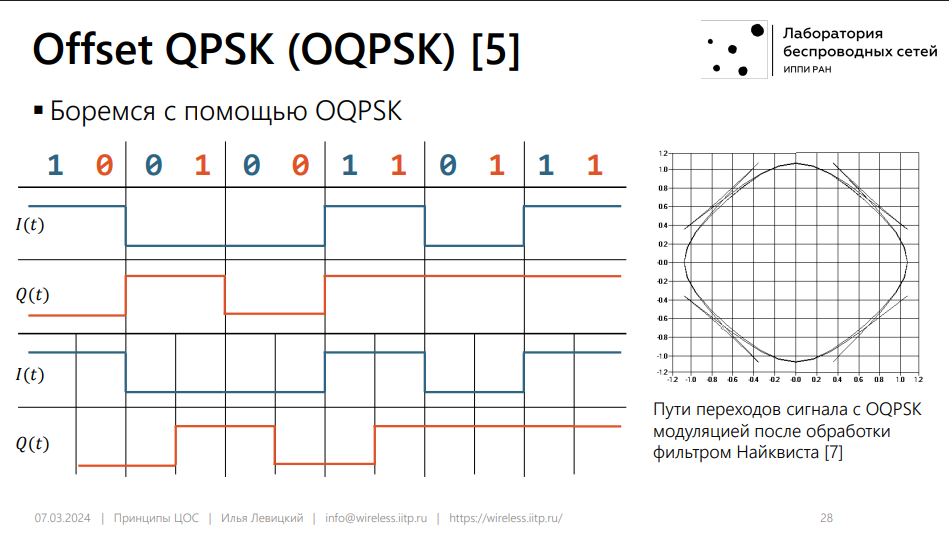
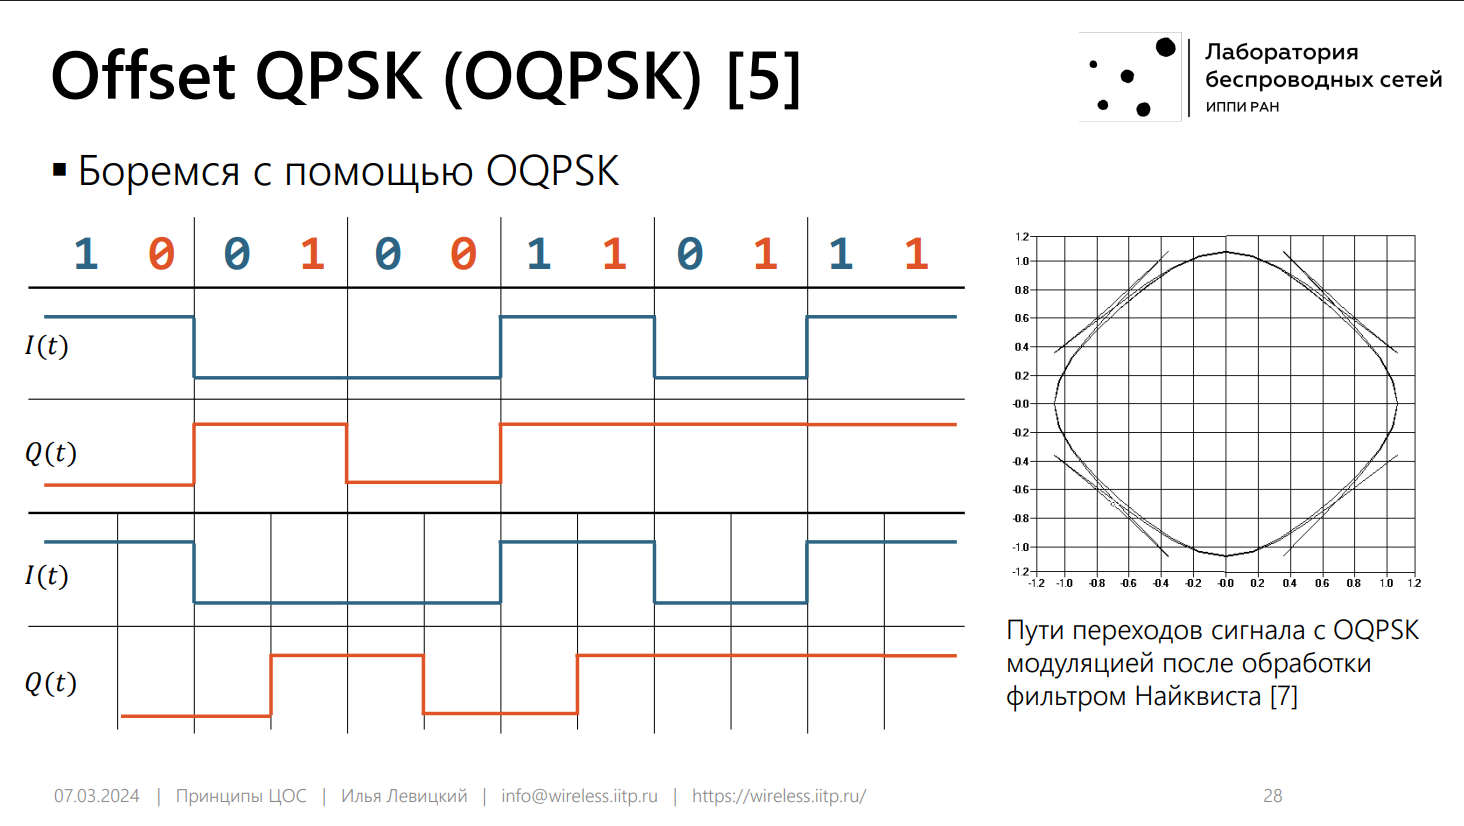

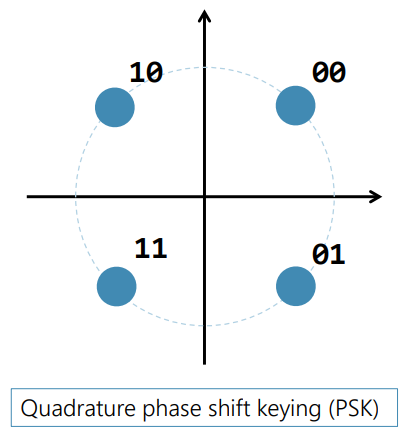
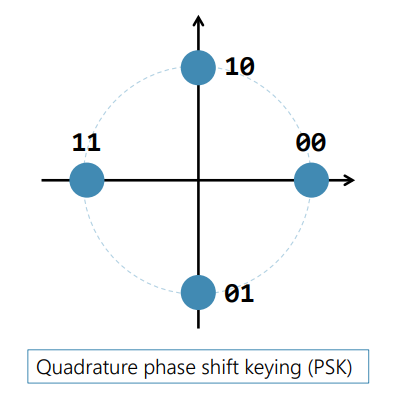

Уравнение OQPSK:
$$ s_{OQPSK}(t) = I(t) \cos(2\pi f_c t) - Q(t - T_s/2) \sin(2\pi f_c t) $$

Как я понимаю, здесь полезный baseband сигнал - это I(t) и Q(t). Поэтому для данного типа модуляции шаг A1 и шаг B1 бесполезен?

In [365]:
def symbols_to_bits(symbols, bits_per_symbol):
    
    # пример: '02b' означает заполнить нулями до 2 знаков, двоичная система (b)
    bit_string = "".join(format(s, f'0{bits_per_symbol}b') for s in symbols)
    
    return np.array([int(b) for b in bit_string])

In [366]:
def bits_to_IQ_QPSK(bits):
    I = np.where(bits[:, 0] == 0, 1, -1)
    Q = np.where(bits[:, 1] == 0, 1, -1)
    
    return I, Q

In [367]:
def modulateIQ(I, Q, f_c, f_s, t=[]):
    dt = 1 / f_s
    
    assert(np.isclose(I, Q).all)
    
    if len(t) == 0:
        t = np.linspace(0, len(I) * dt, len(I))
    
    return I * np.cos(2*np.pi*f_c*t) - Q * np.sin(2*np.pi*f_c*t)

In [368]:
def modulateQPSK(data_symbols, bits_per_symbol, f_c, f_s, t=[]):
    
    I, Q = bits_to_IQ_QPSK(symbols_to_bits(data_symbols, bits_per_symbol))
    
    I_baseband = make_wide(I, samples_per_symbol, scale_multiplier=1)
    Q_baseband = make_wide(Q, samples_per_symbol, scale_multiplier=1)
    
    return modulateIQ(I_baseband, Q_baseband, f_c, f_s, t)

In [369]:
def plot_constellation(I, Q, label=None, linestyle=None, color=None, figsize=(8, 8), plot_track=True):
    
    plt.figure(figsize=figsize)
    
    if plot_track:
        plt.plot(I, Q, color=color, linewidth=0.8, alpha=0.5, label=label, linestyle=linestyle)
        
    plt.scatter(I, Q, color='red')
    
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
    plt.minorticks_on()
    plt.grid(which='minor', 
            linestyle = ':')
    
    plt.xlabel(r'$I$')
    plt.ylabel(r'$Q$')
    
    plt.axis('equal')
    
    plt.legend()

Переводим символы в массив из битов

In [370]:
data_bits = symbols_to_bits(data_symbols, bits_per_symbol).reshape(-1, 2)
display(data_symbols[:10])
display(data_bits[:10])

array([3, 3, 1, 3, 0, 3, 2, 0, 1, 2], dtype=int32)

array([[1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 1],
       [1, 0]])

В соответствии с созвездием переводим символы-биты в IQ последовательность

In [371]:
I, Q = bits_to_IQ_QPSK(data_bits)
display(I[:10])
display(Q[:10])

array([-1, -1,  1, -1,  1, -1, -1,  1,  1, -1])

array([-1, -1, -1, -1,  1, -1,  1,  1, -1,  1])

In [372]:
I_baseband = make_wide(I, samples_per_symbol, scale_multiplier=1)
Q_baseband = make_wide(Q, samples_per_symbol, scale_multiplier=1)

QPSK_signal = modulateIQ(I_baseband, Q_baseband, Fc, Fs, t) / np.sqrt(2)

Делаем задержку Q сигнала на полсимвола

In [373]:
shift_samples = samples_per_symbol // 2
Q_baseband_delayed = np.roll(Q_baseband, shift_samples)
Q_baseband_delayed[:shift_samples] = Q_baseband[0] 

In [374]:


OQPSK_signal = modulateIQ(I_baseband, Q_baseband_delayed, Fc, Fs, t) / np.sqrt(2)

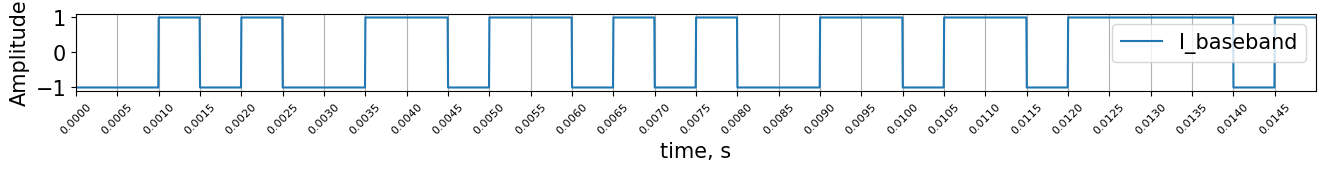

In [375]:
symbols_to_plot = 30

plot_symbols(I_baseband, symbols_to_plot, samples_per_symbol, Fs, label='I_baseband', figsize=(16, 1))

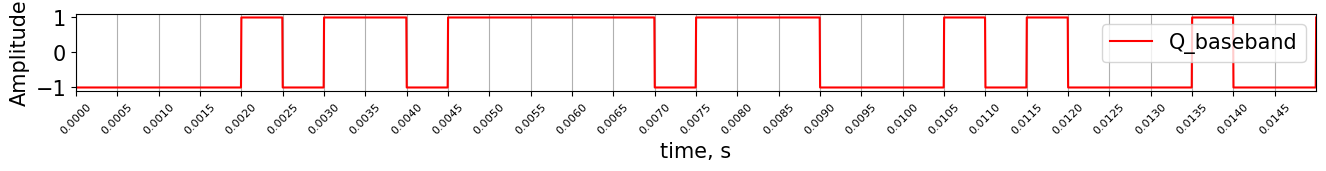

In [376]:
plot_symbols(Q_baseband, symbols_to_plot, samples_per_symbol, Fs, label='Q_baseband', color='r', figsize=(16, 1))

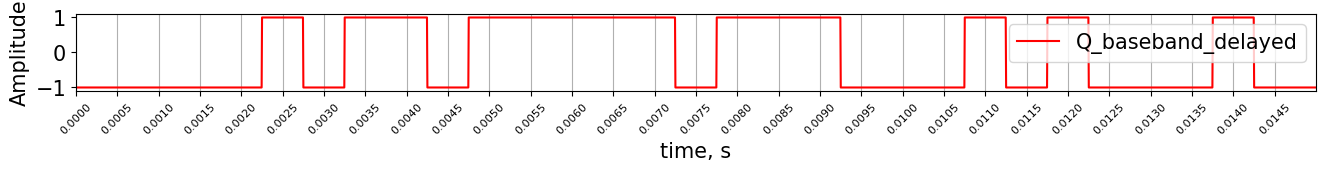

In [377]:
plot_symbols(Q_baseband_delayed, symbols_to_plot, samples_per_symbol, Fs, label='Q_baseband_delayed', color='r', figsize=(16, 1))

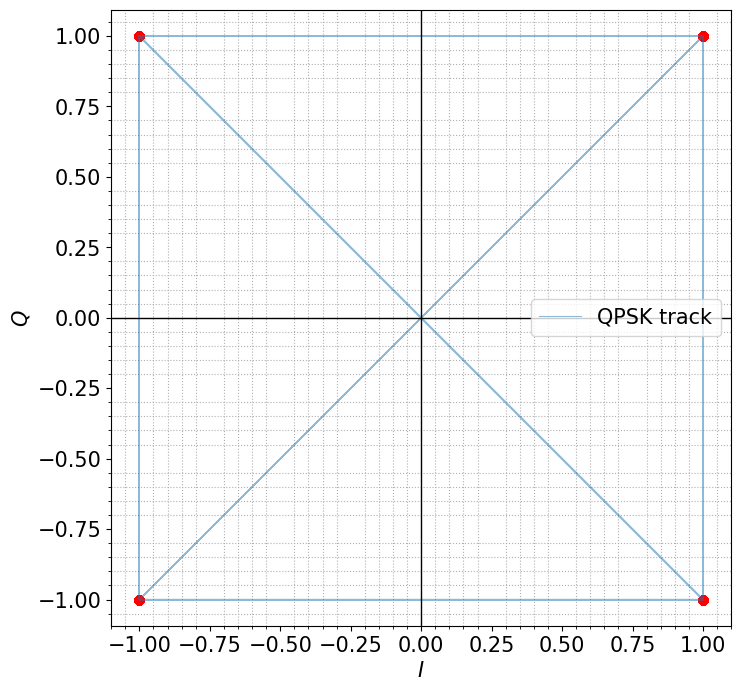

In [378]:
plot_constellation(I_baseband, Q_baseband, label='QPSK track')

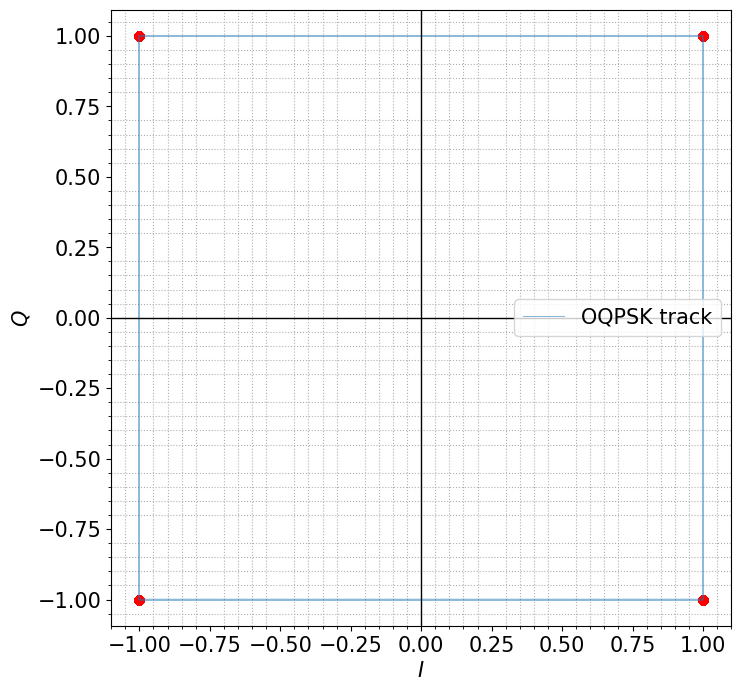

In [379]:
plot_constellation(I_baseband, Q_baseband_delayed, label='OQPSK track')

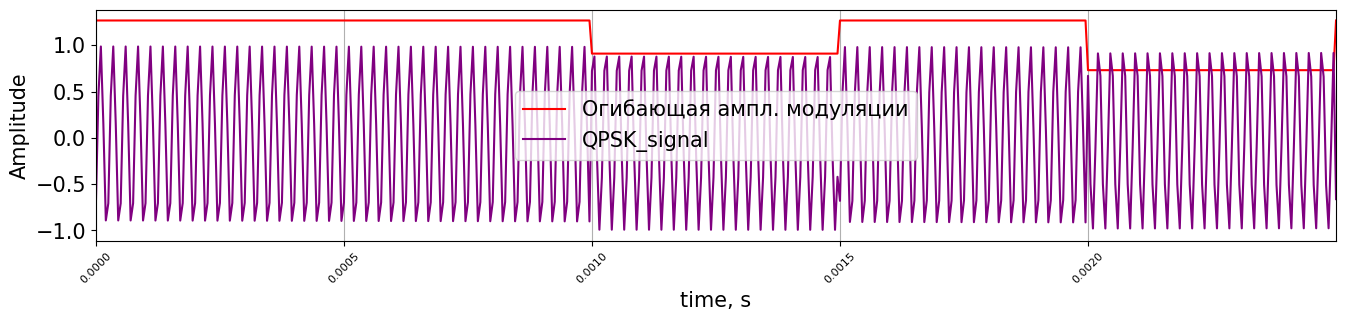

In [380]:
symbols_to_plot = 5

plot_symbols(1+scale_factor*normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
plot_symbols(QPSK_signal, symbols_to_plot, samples_per_symbol, Fs, label='QPSK_signal', color='purple', figsize=(16, 3))

(10.0, 80.0)

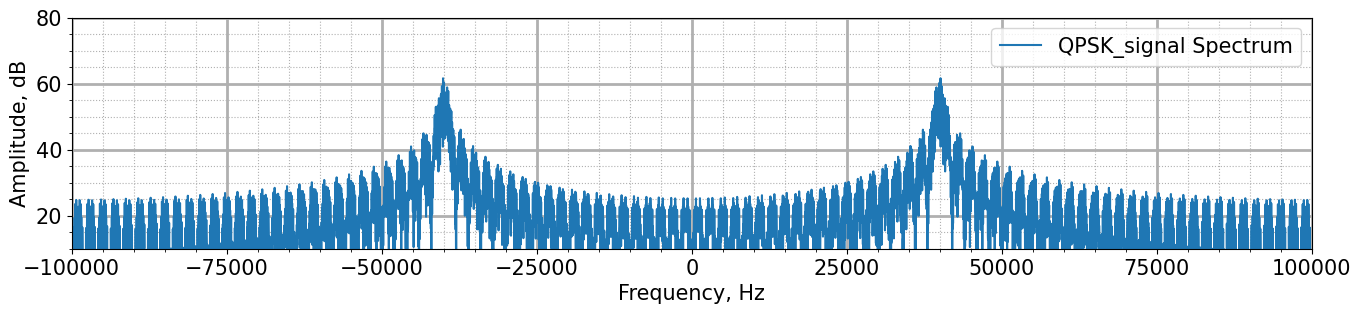

In [381]:
use_log = True
Fmax = Fs / 2
plotAmplFreqResp(QPSK_signal, Fs, Fmax, use_log_scale=use_log, label='QPSK_signal Spectrum')
plt.ylim((10, 80))

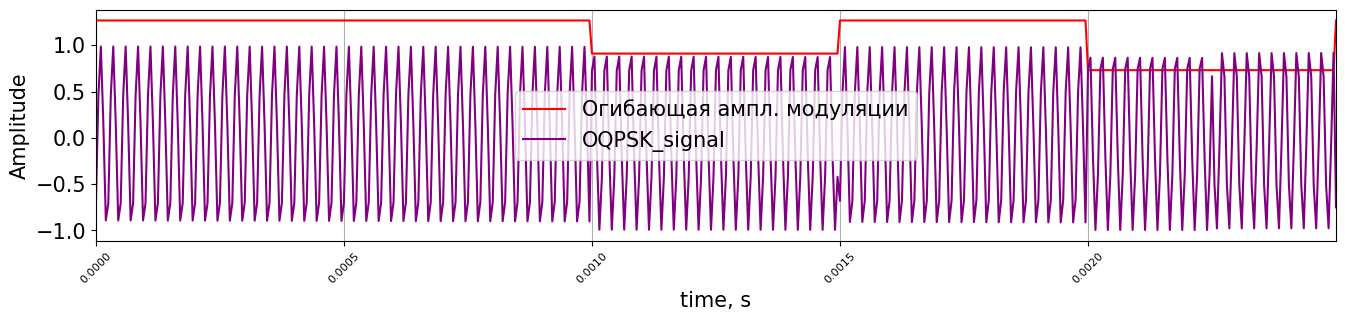

In [382]:
plot_symbols(1+scale_factor*normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
plot_symbols(OQPSK_signal, symbols_to_plot, samples_per_symbol, Fs, label='OQPSK_signal', color='purple', figsize=(16, 3))

(10.0, 80.0)

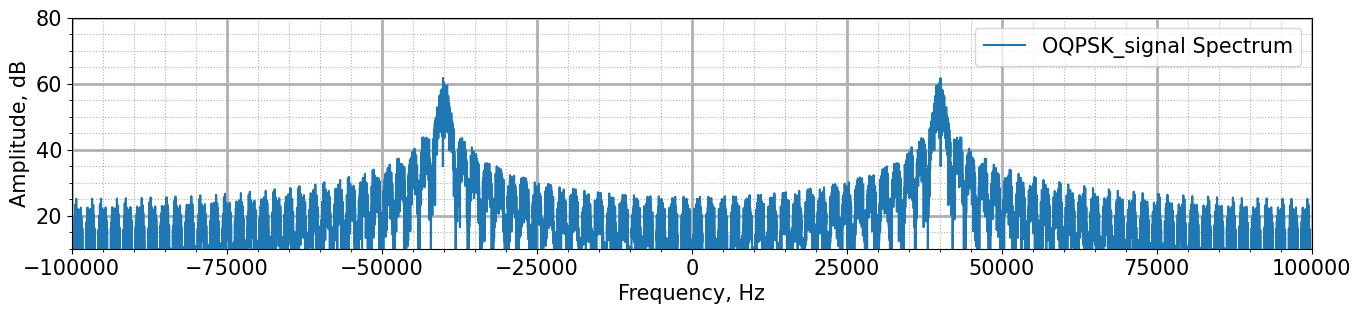

In [383]:
use_log = True
Fmax = Fs / 2
plotAmplFreqResp(OQPSK_signal, Fs, Fmax, use_log_scale=use_log, label='OQPSK_signal Spectrum')
plt.ylim((10, 80))

(10.0, 80.0)

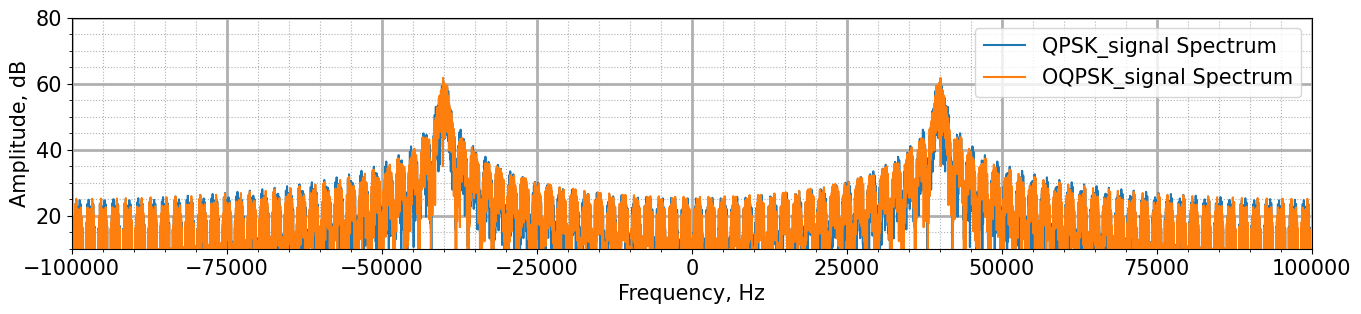

In [384]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(QPSK_signal, Fs, Fmax, use_log_scale=use_log, label='QPSK_signal Spectrum')
plotAmplFreqResp(OQPSK_signal, Fs, Fmax, use_log_scale=use_log, label='OQPSK_signal Spectrum')

plt.ylim((10, 80))

#### HW9*: Write a short theoretical snippet about your modulation.
Consider main attributes, means of modulation and demodulation. Make references if needed.

Не сегодня... Предлагаю лучше пообщаться на сдаче

#### HW10*: For one (**or both) of modulations plot and compare the spectra for different bit rates, but equal baud rates.
NOTE: find the right parameter to change

Прелагаю сравнить BPSK и QPSK с одинаковым бодрейтом (у нас зафиксирован symbol_duration == data_size_symbols * dt'), но разным битрейтом (поскольку в BPSK битрейт = 1 бит/символ, а в QPSK битрейт = 2 бита/символ)

In [385]:
BPSK_baseband = I_baseband # если так сделать, получится BPSK
BPSK_signal = BPSK_baseband * np.cos(2*np.pi*Fc*t)  # I(t) * cos(...)

(-10.0, 80.0)

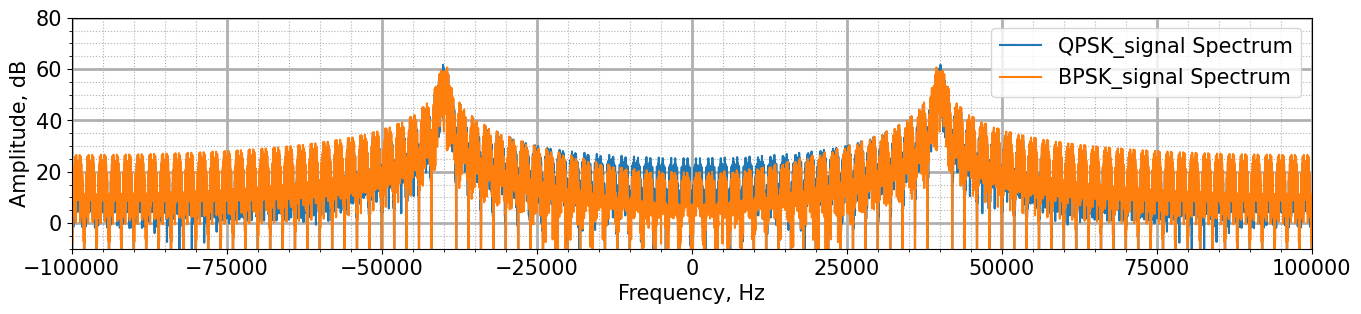

In [386]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(QPSK_signal, Fs, Fmax, use_log_scale=use_log, label='QPSK_signal Spectrum')
plotAmplFreqResp(BPSK_signal, Fs, Fmax, use_log_scale=use_log, label='BPSK_signal Spectrum')

plt.ylim((-10, 80))

Выводы: 
1. При одинаковой длительности символа (одинаковый Baud Rate) ширины лепестков совпадают, что видно у BPSK и OQPSK. Это ясно и из аналитики - ширина лепестка обратна $T_s$
2. При этом OQPSK передает информацию в 2 раза быстрее (Bit rate x2)! Но мы платим тем, что OQPSK менее устойчик к шуму. Чем больше битов приходится на один символ, тем больше допустимых символов, тем ближе друг к другу они располагаются

### HW11: Compare spectra of different modulations, using THE SAME bit sequence. Make conclusions.

Сравним QPSK и CPFSK

(-10.0, 80.0)

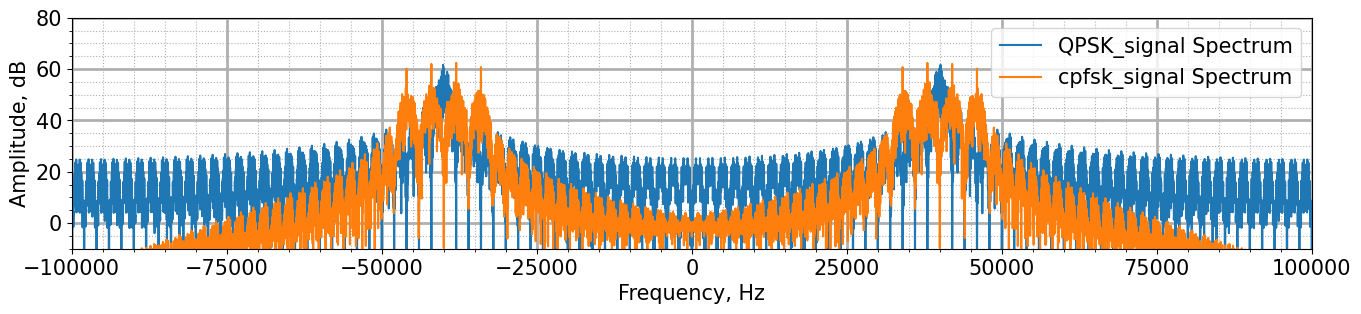

In [387]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(QPSK_signal, Fs, Fmax, use_log_scale=use_log, label='QPSK_signal Spectrum')
plotAmplFreqResp(cpfsk_signal, Fs, Fmax, use_log_scale=use_log, label='cpfsk_signal Spectrum')

plt.ylim((-10, 80))

Выводы:
1. CPFSK занимает очень большую полосу частот по сравнению с QPSK при одном и том же битрейте и бодовой скорости (что логично - каждый символ это своя частота)
2. Но в то же время скорость спада боковых лепестков у CPFSK больше, что плюс (потому что функция получается непрерывной - разрывов в фазе нет)

## D - Channel

### HW: Apply AWGN (Additive White Gaussian Noise) to the transmitted signal.
Use SNR in dB as input parameter for noise power.

Find three values for SNR, where bit error rate is roughly 8-12%; 0.5-2%; 0.1-0.05%.

$$SNR_{dB} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)$$
$$P_{signal} = \frac{1}{N} \sum_{i=1}^{N} |x_i|^2$$
$$SNR_{linear} = 10^{\frac{SNR_{dB}}{10}}$$
$$\sigma = \sqrt{P_{noise}} = \sqrt{\frac{P_{signal}}{SNR_{linear}}}$$

In [388]:
def get_sigma_from_snr(signal, snr_db):
    sig_power = np.mean(np.abs(signal)**2)
    snr_linear = 10**(snr_db / 10)
    
    return np.sqrt(sig_power / snr_linear)

In [389]:
symbols_to_plot = 5

make_noise = True

modulated_signal = cpfsk_signal

snr_db = 15  # dB
sigma = get_sigma_from_snr(modulated_signal, snr_db)
display(sigma)
noise = np.random.normal(loc=0, scale=sigma, size=len(modulated_signal)) if make_noise else np.tile(0, len(modulated_signal))

transmitted_modulated_signal = modulated_signal + noise

np.float64(0.12574923713084385)

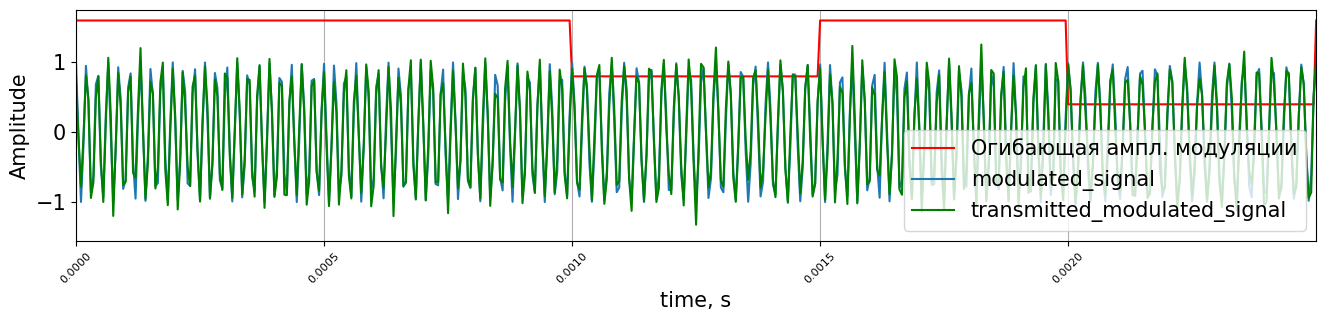

In [390]:
plot_symbols(1+scale_factor*baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
# plot_symbols(-(1+scale_factor*baseband_signal), symbols_to_plot, samples_per_symbol, Fs, color='red')
plot_symbols(modulated_signal, symbols_to_plot, samples_per_symbol, Fs, label='modulated_signal')
plot_symbols(transmitted_modulated_signal, symbols_to_plot, samples_per_symbol, Fs, label='transmitted_modulated_signal', color='green')

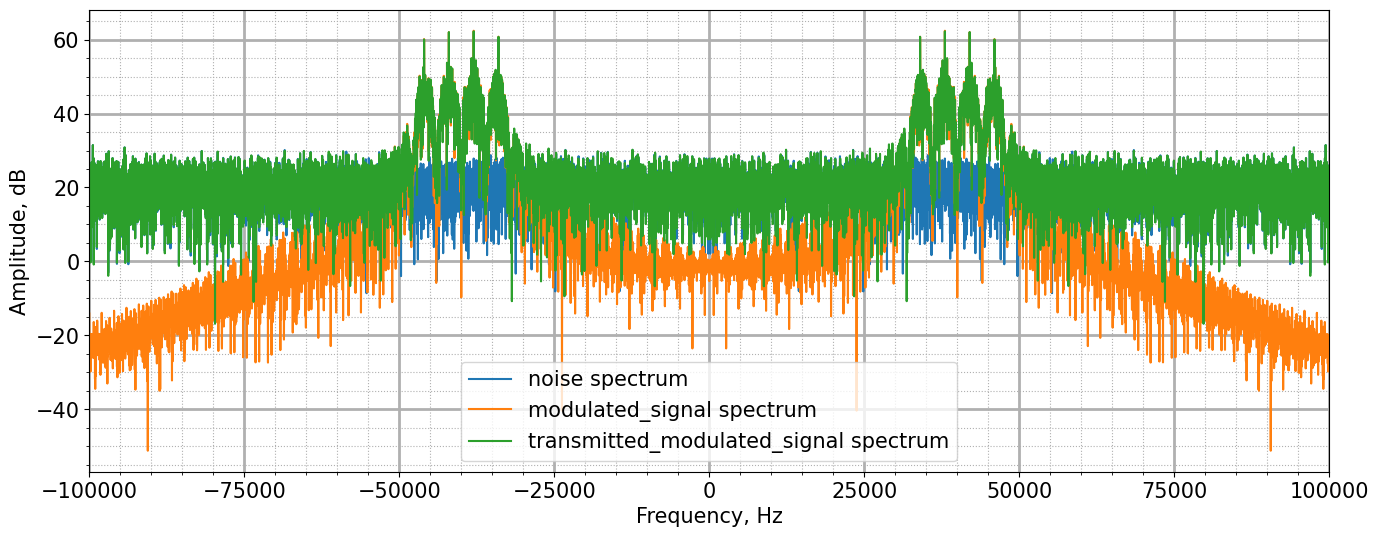

In [391]:
use_log = True
Fmax = Fs / 2 / 1

plotAmplFreqResp(noise, Fs, Fmax, use_log_scale=use_log, label='noise spectrum', figsize=(16, 6))
plotAmplFreqResp(modulated_signal, Fs, Fmax, use_log_scale=use_log, label='modulated_signal spectrum', figsize=(16, 6))
plotAmplFreqResp(transmitted_modulated_signal, Fs, Fmax, use_log_scale=use_log, label='transmitted_modulated_signal spectrum', figsize=(16, 6))

# ask_pulse_signal = modulateAM(pulse_signal, Fc, Fs, m, t)
# plotAmplFreqResp(ask_pulse_signal, Fs, Fmax, use_log_scale=use_log, label='ask_pulse_signal spectrum', figsize=(16, 6))

# plt.ylim((-10, 70))

## C2 - Demodulation

### HW12: Perform demodulation - scale_multiplier by a carrier.
NOTE: Apply LPF to the transmitted signal to remove high-frequency noise on stage B2!

NOTE: You MAY apply passband filter BEFORE scale_multipliering by a carrier to remove extra noise.

In [392]:
bandwith_half_to_filter = 30_000

In [393]:
Fc - bandwith_half_to_filter - 500

9500

In [394]:
bpf = sg.iirdesign(wp=[Fc - bandwith_half_to_filter      , Fc + bandwith_half_to_filter      ], 
                   ws=[Fc - bandwith_half_to_filter - 500, Fc + bandwith_half_to_filter + 500], 
                   gpass=0.01, gstop=100, fs=Fs, output='sos')

# Фильтруем зашумленный сигнал ДО демодуляции
transmitted_modulated_signal_clean = sg.sosfiltfilt(bpf, transmitted_modulated_signal)

In [395]:
restored_modulated_signal_not_filtered = transmitted_modulated_signal_clean * np.exp(-1j*2 * np.pi * Fc * t)

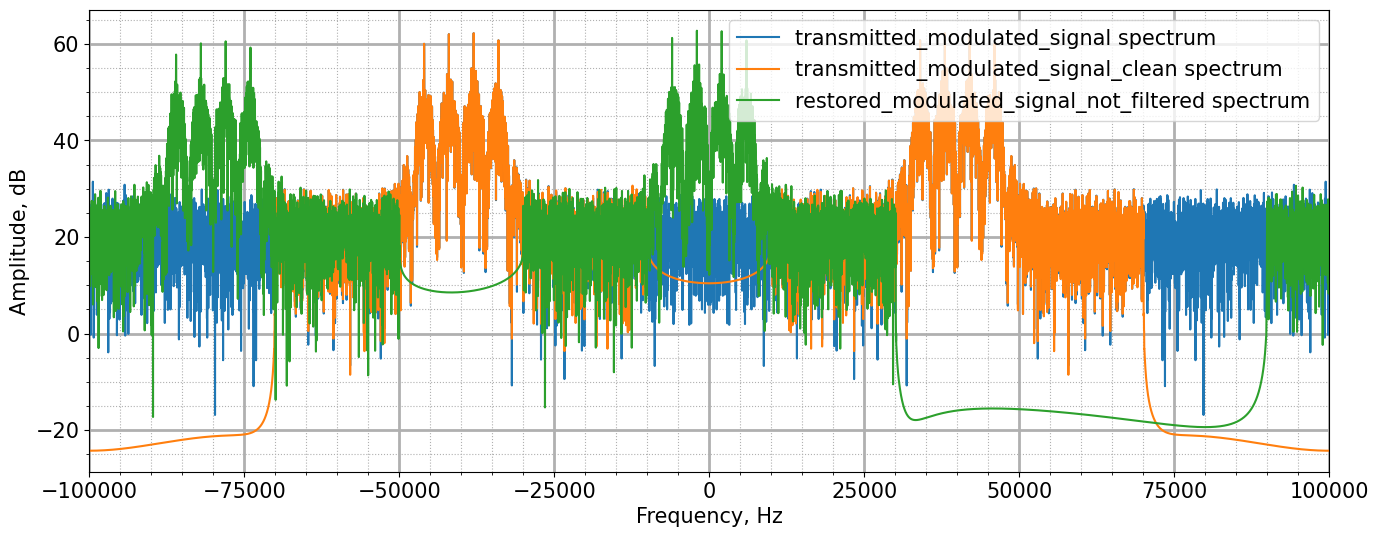

In [396]:
use_log = True
Fmax = Fs / 2 / 1

plotAmplFreqResp(transmitted_modulated_signal, Fs, Fmax, use_log_scale=use_log, label='transmitted_modulated_signal spectrum', figsize=(16, 6))
plotAmplFreqResp(transmitted_modulated_signal_clean, Fs, Fmax, use_log_scale=use_log, label='transmitted_modulated_signal_clean spectrum', figsize=(16, 6))
plotAmplFreqResp(restored_modulated_signal_not_filtered, Fs, Fmax, use_log_scale=use_log, label='restored_modulated_signal_not_filtered spectrum', figsize=(16, 6))

# plt.ylim((-10, 70))

## B2 - Demodulation filter

### HW2: Realize a filter

Recall your number N. Update N = GROUP_SIZE - N.

Select filter x = N mod 6 and realize it:

 0) Butterworth
 1) Chebyshev I
 2) Chebyshev II
 3) Elliptic
 4) Gaussian
 5) Bessel

You may consult yourself, starting from here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html
Use either analog mode or digital mode with correct sampling rate.
If want to change or select another than ones from the list, contact teacher :)

Build your filter according to the following criteria:
 Gp = -1 dB, 
 Gs = -70 dB, 
 fp = 10 kHz, 
 fs = 11 kHz, 
If criteria are too harsh for your filter, contact teacher :)

UPD:

Ctiterias:
Gp = -1 dB, 
fp = 10 kHz, 

In [397]:
fp = 16500 # 25000 # Hz
fp_ordered = 10000  

# fs = 11000  # Hz
gpass = 1   # Gp = -1 dB
# gstop = 70  # Gs = -70 dB

order = 80
sos_bessel = sg.bessel(N=order, Wn=fp, btype='low', fs=Fs, norm='mag', output='sos')

### HW3: Draw the amplitude-frequency response and phase-frequency response of the filter.
Use format similar to the example from the your last work. 
Add a group delay to the plot.

#### HW4*: Add a proper legend



#### HW5*: Demostrate on the squared amplitude-frequency response that your filter satisfies the criteria. 
Use visual proofs, similar to those in the presentations, to show that Gp, Gs, fp, fs are respected. 

In [398]:
Fmax = Fs / 2

use_log = True

(-20.0, 1.0)

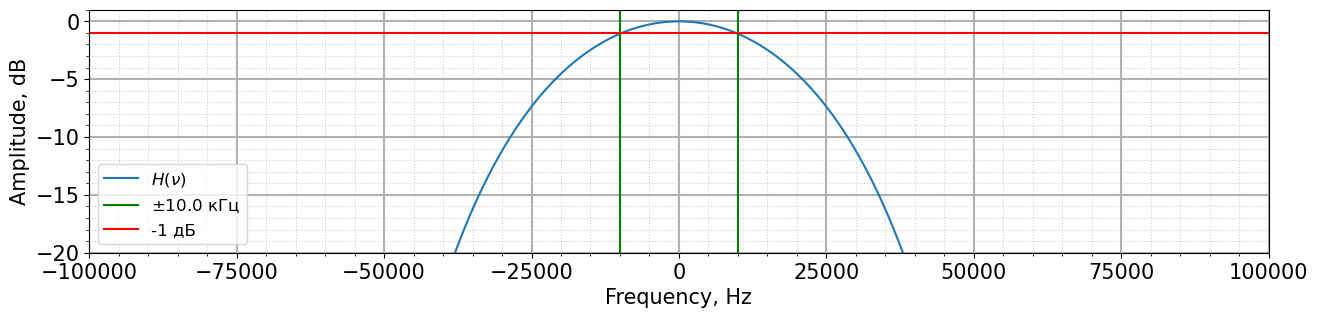

In [399]:
plotAmplFreqRespOfFilter(sos_bessel, Fs, Fmax, use_log_scale=use_log, label=rf'$H(\nu)$')

plt.axvline(fp_ordered, label=rf"$\pm {fp_ordered / 1000}$ кГц", color='green')
plt.axvline(-fp_ordered, color='green')

plt.axhline(-gpass, label=f"-{gpass} дБ", color='red')

plt.legend()

plt.ylim((-20, 1))

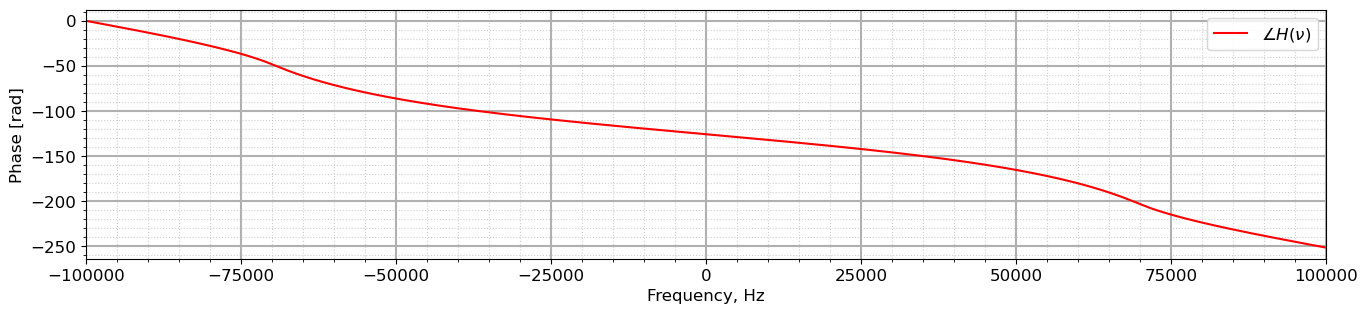

In [400]:
plotPhaseFreqRespOfFilter(sos_bessel, Fs, Fmax, label=rf'$\angle H(\nu)$', color='red')

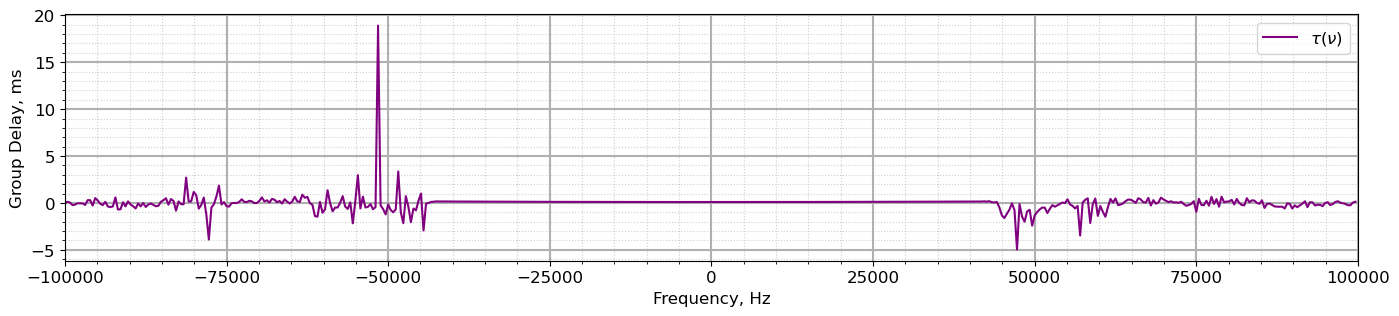

In [401]:
plotGroupDelayOfFilter(sos_bessel, Fs, Fmax, label=rf'$\tau(\nu)$', color='purple')

In [402]:
#Note: After completeing, move sections C1 and C2 inbetween A1 and B2. 

In [403]:
restored_modulated_signal_filtered = sg.sosfiltfilt(sos_bessel, restored_modulated_signal_not_filtered)

(-20.0, 60.0)

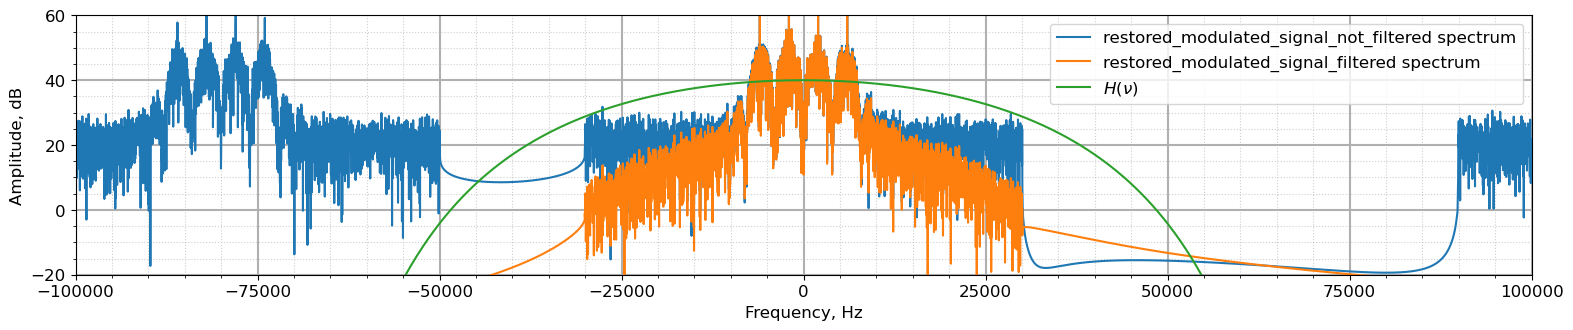

In [404]:
use_log = True
Fmax = Fs / 2 / 1

plotAmplFreqResp(restored_modulated_signal_not_filtered, Fs, Fmax, use_log_scale=use_log, label='restored_modulated_signal_not_filtered spectrum', figsize=(16, 6))
plotAmplFreqResp(restored_modulated_signal_filtered, Fs, Fmax, use_log_scale=use_log, label='restored_modulated_signal_filtered spectrum', figsize=(16, 6))
plotAmplFreqRespOfFilter(sos_bessel, Fs, Fmax, use_log_scale=use_log, label=rf'$H(\nu)$', multiplier=100)

plt.ylim((-20, 60))

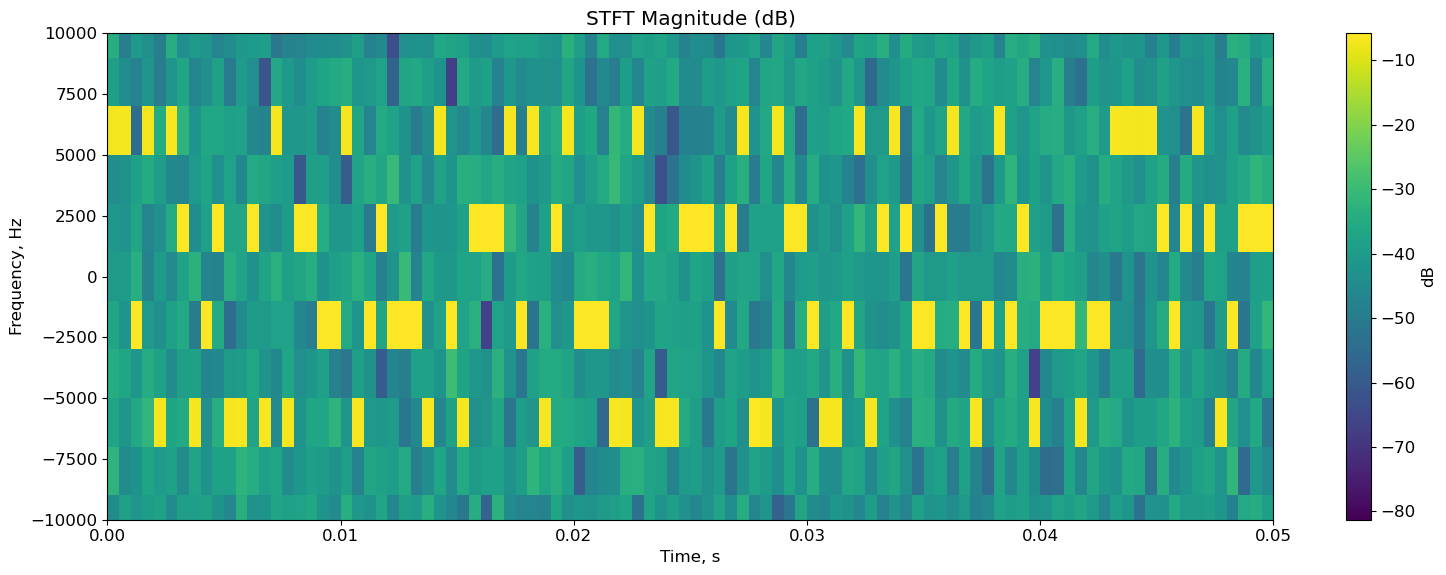

In [405]:
plotSTFT(restored_modulated_signal_filtered[0:samples_per_symbol*100], 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol, 
         Fmax=10000,
         use_log_scale=True)

restored_modulated_signal_filtered = $\mathrm{exp}
( 2 \pi Fd \cdot \int s_m(t) dt )$

In [407]:
restored_cumsum_of_s_m = np.unwrap(np.angle(restored_modulated_signal_filtered)) / (2 * np.pi * Fd * dt)
baseband_discrete_levels_restored = np.diff(restored_cumsum_of_s_m)


baseband_discrete_levels_restored = np.insert(baseband_discrete_levels_restored, 0, baseband_discrete_levels_restored[1])  # Попыктки убрать артефакты от такого грубого дифференцирования
baseband_discrete_levels_restored[1] = baseband_discrete_levels_restored[2]
baseband_discrete_levels_restored[-1] = baseband_discrete_levels_restored[-2]

(-10.0, 10.0)

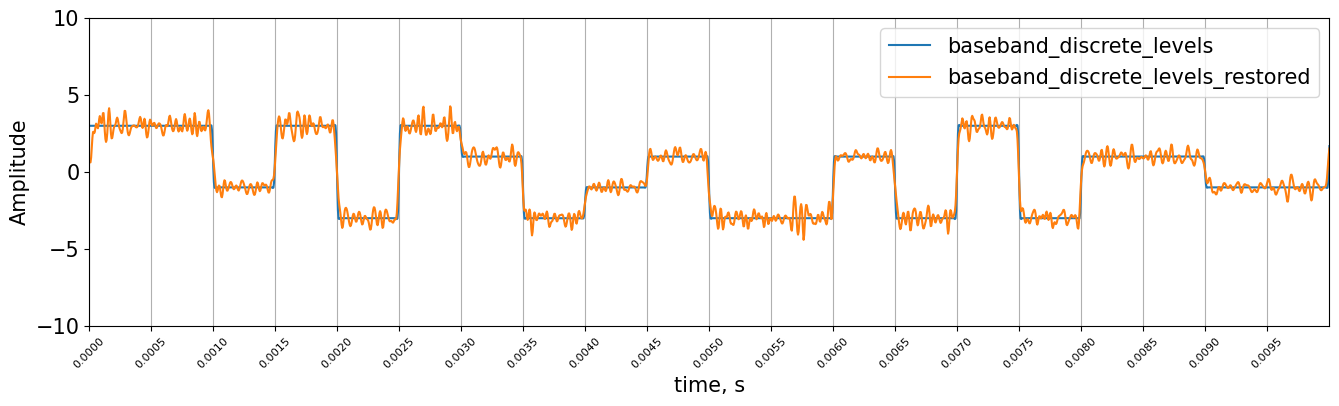

In [408]:
symbols_to_plot = 20

plot_symbols(baseband_discrete_levels, symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels')
plot_symbols(baseband_discrete_levels_restored, symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored', figsize=(16, 4))

plt.ylim(-10, 10)

## A2 - Detection

### HW1: Make hard-decision decoding for your digital signal. Compare the received bit sequence with the transmitted one: make a bit error rate (BER) calculator.

In [409]:
def symbols_to_bits(symbols, bps):
    
    # '02b' означает: заполнить нулями до 2 знаков, двоичная система (b)
    bit_string = "".join(format(s, f'0{bps}b') for s in symbols)
    
    return np.array([int(b) for b in bit_string])

def calculate_BER(original_bits, decoded_bits):
    errors = np.sum(original_bits != decoded_bits)
    return errors / len(original_bits), errors
    

In [410]:
baseband_discrete_levels_restored

array([ 0.6241802 ,  0.6241802 ,  0.6241802 , ..., -0.45805546,
       -0.389422  , -0.389422  ], shape=(10000,))

In [411]:
def detect_by_avaraging(data_symbols_noised: np.ndarray, samples_per_symbol):
    data_symbols_noised_reshaped = data_symbols_noised.reshape(-1, samples_per_symbol)
    data_symbols_avaraged = np.mean(data_symbols_noised_reshaped, axis=1)
    return data_symbols_avaraged.flatten()

def detect_by_center_sampling(data_symbols_noised: np.ndarray, samples_per_symbol):
    return data_symbols_noised[samples_per_symbol//2 :: samples_per_symbol]

In [412]:
# NOTE: After completeing, move B2 section inbetween A1 and A2.

# Берем по одному отсчету на символ посердине (индекс 50, 150, 250 и т.д.)
detected_signal = detect_by_avaraging(baseband_discrete_levels_restored, samples_per_symbol)


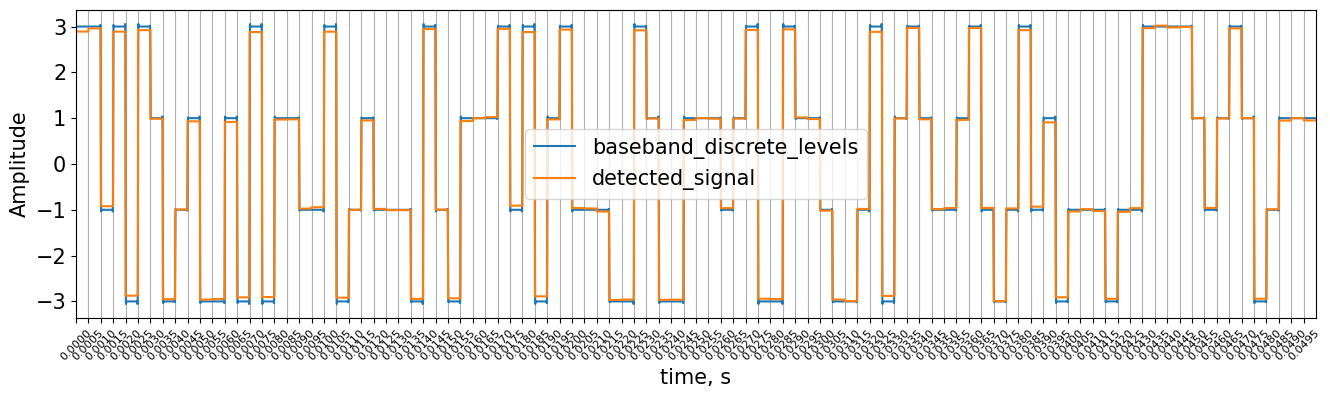

In [413]:
symbols_to_plot = 100

plot_symbols(baseband_discrete_levels, symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels')
plot_symbols(make_wide(detected_signal, samples_per_symbol, scale_multiplier=1), symbols_to_plot, samples_per_symbol, Fs, label='detected_signal', figsize=(16, 4))

# plt.ylim(-5, 5)

Количество ошибочных символов: 0
Количество ошибочных бит: 0
BER (Bit Error Rate): 0.0000


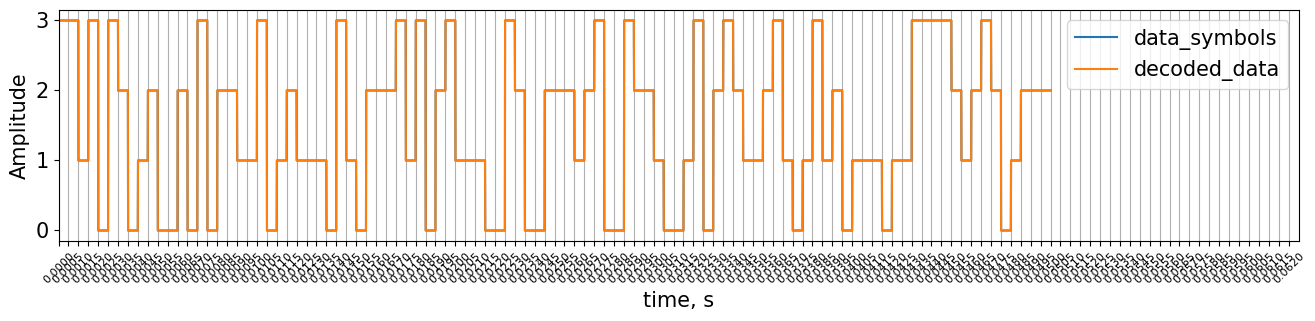

In [414]:

restored_signal = detected_signal # * norm_factor
restored_symbols = (restored_signal + alphabet_size - 1) / 2

decoded_data = np.round(restored_symbols).astype(int)
decoded_data = np.clip(decoded_data, 0, alphabet_size - 1)

original_bits = symbols_to_bits(data_symbols, bits_per_symbol)
decoded_bits = symbols_to_bits(decoded_data, bits_per_symbol)

# BER
ber, errors = calculate_BER(original_bits, decoded_bits)

symbol_errors = np.sum(data_symbols != decoded_data)

print(f"Количество ошибочных символов: {symbol_errors}")
print(f"Количество ошибочных бит: {errors}")
print(f"BER (Bit Error Rate): {ber:.4f}")

symbols_to_plot = 125

plot_symbols(make_wide(data_symbols, samples_per_symbol, scale_multiplier=1),    symbols_to_plot, samples_per_symbol, Fs, label='data_symbols')
plot_symbols(make_wide(decoded_data, samples_per_symbol, scale_multiplier=1), symbols_to_plot, samples_per_symbol, Fs, label='decoded_data')

## Extra1*: Repeat all process through A1 to A2 for your NORMAL modulation instead of EASY.

## Extra2**: For the demodulated baseband signal, plot the EYE DIAGRAM.

## Extra3**: Effect of filter with non-linear phase
See the task in the presentation about filters. Describe all the results. Ask teacher if any questions.